<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color: #e8f5e9; text-align: center;">
  <strong style="font-size: 32px;">REDES NEURONALES ARTIFICIALES - PARTE CUATRO</strong>
</div>

# APLICACIONES

## Predicción

C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


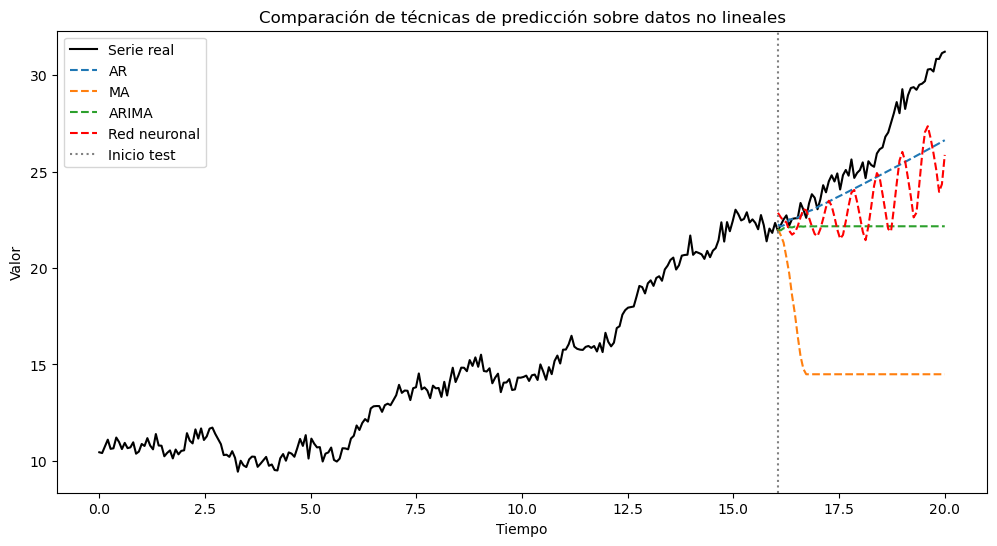

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Datos sintéticos con patrón no lineal
np.random.seed(42)
n = 300
t = np.linspace(0, 20, n)
y = 10 + np.sin(t) + 0.5*np.sin(3*t) + 0.3*np.cos(5*t) + 0.05*t**2 + np.random.normal(scale=0.3, size=n)

# -----------------------------
# División en entrenamiento y prueba
train_size = int(0.8 * n)
y_train, y_test = y[:train_size], y[train_size:]
t_train, t_test = t[:train_size], t[train_size:]

# -----------------------------
# Modelo AR
model_ar = AutoReg(y_train, lags=10).fit()
y_pred_ar = model_ar.predict(start=train_size, end=n-1)

# -----------------------------
# Modelo MA (como ARIMA(0,0,10))
model_ma = ARIMA(y_train, order=(0,0,10)).fit()
y_pred_ma = model_ma.predict(start=train_size, end=n-1)

# -----------------------------
# Modelo ARIMA(p,d,q): AR(3), d=1, MA(3)
model_arima = ARIMA(y_train, order=(3,1,3)).fit()
y_pred_arima = model_arima.predict(start=train_size, end=n-1, typ='levels')

# -----------------------------
# Red neuronal
max_lag = 10
X_nn = np.column_stack([y_train[max_lag - lag:-(lag)] for lag in range(1, max_lag+1)])
y_nn = y_train[max_lag:]

# Normalización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_nn)

# Entrenamiento
nn = MLPRegressor(hidden_layer_sizes=(64,64), activation='relu', max_iter=5000, random_state=0)
nn.fit(X_scaled, y_nn)

# Predicciones autoregresivas
preds = list(y_train[-max_lag:])
y_pred_nn = []

for _ in range(len(y_test)):
    x_input = np.array(preds[-max_lag:]).reshape(1,-1)
    x_input_scaled = scaler.transform(x_input)
    y_next = nn.predict(x_input_scaled)[0]
    y_pred_nn.append(y_next)
    preds.append(y_next)

# -----------------------------
# Visualización
plt.figure(figsize=(12,6))
plt.plot(t, y, label='Serie real', color='black')
plt.plot(t_test, y_pred_ar, label='AR', linestyle='--')
plt.plot(t_test, y_pred_ma, label='MA', linestyle='--')
plt.plot(t_test, y_pred_arima, label='ARIMA', linestyle='--')
plt.plot(t_test, y_pred_nn, label='Red neuronal', linestyle='--', color='red')
plt.axvline(t[train_size], color='gray', linestyle=':', label='Inicio test')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.title('Comparación de técnicas de predicción sobre datos no lineales')
plt.legend()
plt.show()


## Predicción del número mensual de pasajeros de aerolíneas internacionales a partir de los valores pasados de la misma serie, usando modelos clásicos (AR, MA, ARIMA) y una red neuronal

- Los datos provienen del dataset clásico AirPassengers, que contiene el número de pasajeros internacionales registrados cada mes desde enero de 1949 hasta diciembre de 1960.

C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warn

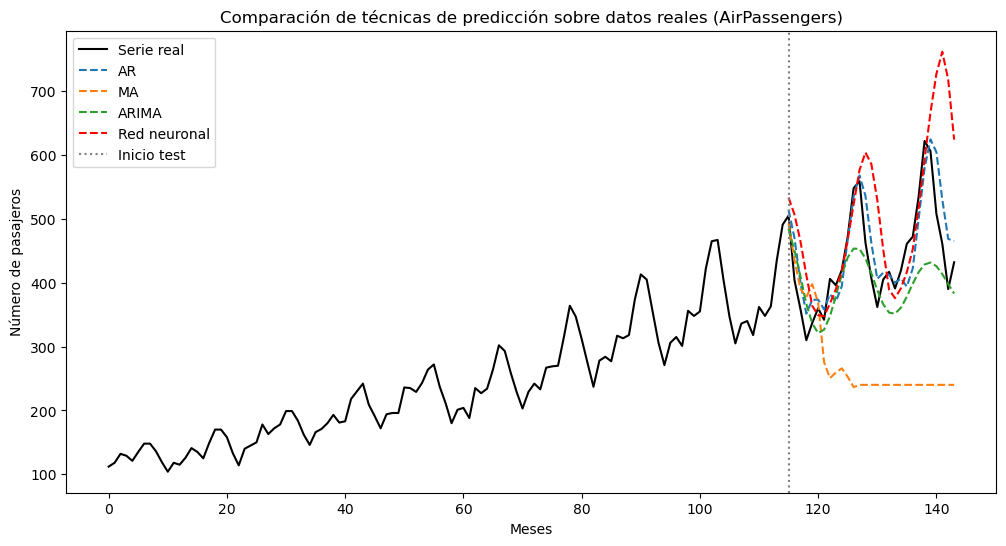

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Cargar datos reales: AirPassengers desde CSV
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, usecols=['Passengers'])
data = df['Passengers'].values
t = np.arange(len(data))

# -----------------------------
# División en entrenamiento y prueba
n = len(data)
train_size = int(0.8 * n)
y_train, y_test = data[:train_size], data[train_size:]
t_train, t_test = t[:train_size], t[train_size:]

# -----------------------------
# Modelo AR
model_ar = AutoReg(y_train, lags=12).fit()
y_pred_ar = model_ar.predict(start=train_size, end=n-1)

# -----------------------------
# Modelo MA (como ARIMA(0,0,12))
model_ma = ARIMA(y_train, order=(0,0,12)).fit()
y_pred_ma = model_ma.predict(start=train_size, end=n-1)

# -----------------------------
# Modelo ARIMA(p,d,q)
model_arima = ARIMA(y_train, order=(3,1,3)).fit()
y_pred_arima = model_arima.predict(start=train_size, end=n-1, typ='levels')

# -----------------------------
# Red neuronal como predictor
max_lag = 12
X_nn = np.column_stack([y_train[max_lag - lag:-(lag)] for lag in range(1, max_lag+1)])
y_nn = y_train[max_lag:]

# Normaliza
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_nn)

# Entrena
nn = MLPRegressor(hidden_layer_sizes=(64,64), activation='relu', max_iter=5000, random_state=0)
nn.fit(X_scaled, y_nn)

# Predicciones autoregresivas
preds = list(y_train[-max_lag:])
y_pred_nn = []

for _ in range(len(y_test)):
    x_input = np.array(preds[-max_lag:]).reshape(1,-1)
    x_input_scaled = scaler.transform(x_input)
    y_next = nn.predict(x_input_scaled)[0]
    y_pred_nn.append(y_next)
    preds.append(y_next)

# -----------------------------
# Visualización
plt.figure(figsize=(12,6))
plt.plot(t, data, label='Serie real', color='black')
plt.plot(t_test, y_pred_ar, label='AR', linestyle='--')
plt.plot(t_test, y_pred_ma, label='MA', linestyle='--')
plt.plot(t_test, y_pred_arima, label='ARIMA', linestyle='--')
plt.plot(t_test, y_pred_nn, label='Red neuronal', linestyle='--', color='red')
plt.axvline(t[train_size], color='gray', linestyle=':', label='Inicio test')
plt.xlabel('Meses')
plt.ylabel('Número de pasajeros')
plt.title('Comparación de técnicas de predicción sobre datos reales (AirPassengers)')
plt.legend()
plt.show()


## Regresión


Primeros 5 valores de área (X) y precio (y):
Área (m²): [0.        0.1010101 0.2020202 0.3030303 0.4040404]
Precio (miles de USD): [0.00088203 0.00040176 0.00089067 0.00171727 0.00172005]

Tamaño de los vectores:
Shape de X: (100, 1)
Shape de y: (100,)

Regresión lineal:
Precio = 0.64 + -0.05·Área

Regresión polinómica (grado 2):
Precio = 0.13 + 0.00 + 4.10·Área^1 + -2.44·Área^2 + 0.42·Área^3 + -0.02·Área^4

Regresión múltiple (Área y Área^2):
Precio = 2.23 + -1.02·Área + 0.10·Área^2

Regresión con red neuronal:
Modelo con capas: [1,64,64,64,1] entrenado.


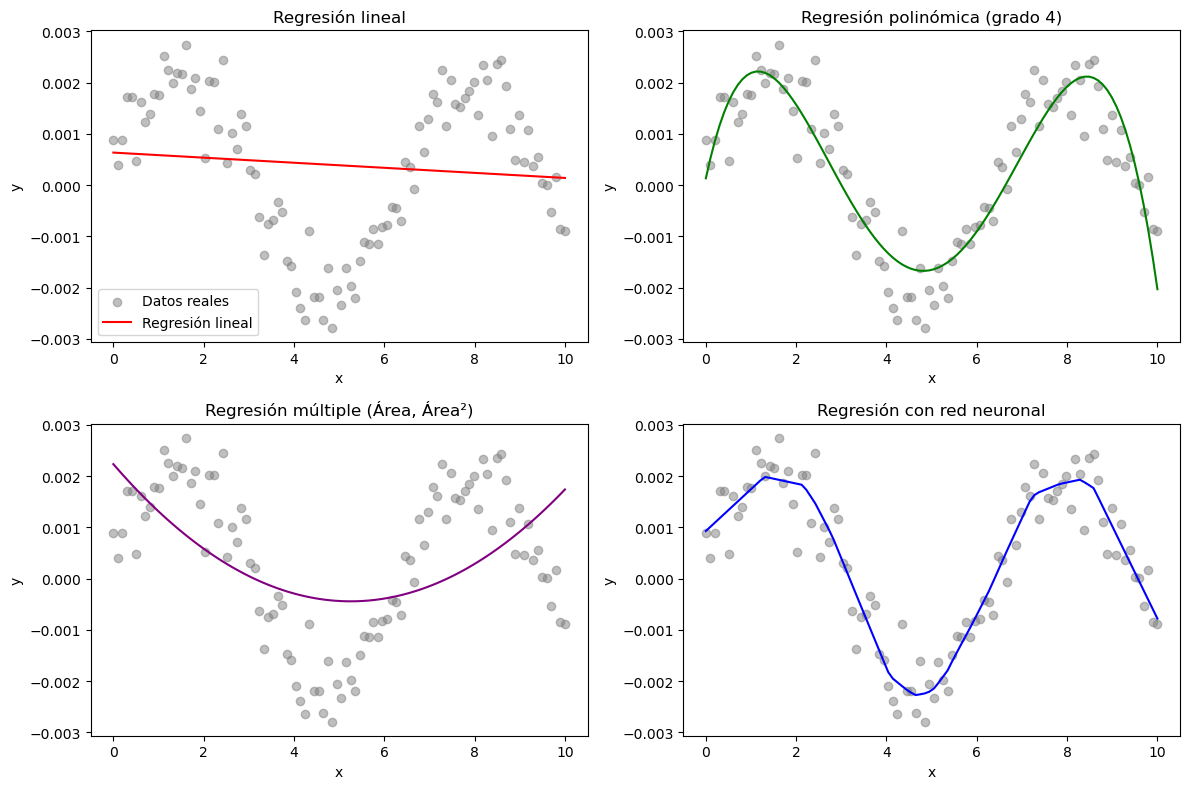

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.neural_network import MLPRegressor

# -----------------------------
# Datos sintéticos
np.random.seed(0)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 2 * np.sin(X).ravel() + np.random.normal(scale=0.5, size=100)

# Mostrar algunos valores y tamaño
print("\nPrimeros 5 valores de área (X) y precio (y):")
print("Área (m²):", X[:5].ravel())
print("Precio (miles de USD):", y[:5]/1000)

print("\nTamaño de los vectores:")
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

# -----------------------------
# Regresión lineal
model_linear = LinearRegression()
model_linear.fit(X, y)
print("\nRegresión lineal:")
print(f"Precio = {model_linear.intercept_:.2f} + {model_linear.coef_[0]:.2f}·Área")

# -----------------------------
# Regresión polinómica (grado 4)
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)
model_poly = LinearRegression()
model_poly.fit(X_poly, y)
print("\nRegresión polinómica (grado 2):")
terms = [f"{coef:.2f}" if i==0 else f"{coef:.2f}·Área^{i}" for i, coef in enumerate(model_poly.coef_)]
equation_poly = " + ".join(terms)
print(f"Precio = {model_poly.intercept_:.2f} + {equation_poly}")

# -----------------------------
# Regresión múltiple (Área y Área^2)
X_multi = np.hstack((X, X**2))
model_multi = LinearRegression()
model_multi.fit(X_multi, y)
print("\nRegresión múltiple (Área y Área^2):")
print(f"Precio = {model_multi.intercept_:.2f} + {model_multi.coef_[0]:.2f}·Área + {model_multi.coef_[1]:.2f}·Área^2")

# -----------------------------
# Regresión con red neuronal (estructura [1,64,64,64,1])
# Escalamos X para que la red neuronal entrene mejor
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

nn = MLPRegressor(hidden_layer_sizes=(64,64,64), activation='relu', max_iter=2000, random_state=0)
nn.fit(X_scaled, y)
print("\nRegresión con red neuronal:")
print("Modelo con capas: [1,64,64,64,1] entrenado.")

# Predicciones con red neuronal
y_nn_pred = nn.predict(X_scaled)

# -----------------------------
# Visualización
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.scatter(X, y/1000, color='gray', alpha=0.5, label='Datos reales')
plt.plot(X, model_linear.predict(X)/1000, color='red', label='Regresión lineal')
plt.title('Regresión lineal')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.subplot(2, 2, 2)
plt.scatter(X, y/1000, color='gray', alpha=0.5)
plt.plot(X, model_poly.predict(X_poly)/1000, color='green')
plt.title('Regresión polinómica (grado 4)')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(2, 2, 3)
plt.scatter(X, y/1000, color='gray', alpha=0.5)
plt.plot(X, model_multi.predict(X_multi)/1000, color='purple')
plt.title('Regresión múltiple (Área, Área²)')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(2, 2, 4)
plt.scatter(X, y/1000, color='gray', alpha=0.5)
plt.plot(X, y_nn_pred/1000, color='blue')
plt.title('Regresión con red neuronal')
plt.xlabel('x')
plt.ylabel('y')

plt.tight_layout()
plt.show()

## Dataset: CO₂ en Mauna Loa (Hawái)

Serie temporal mensual de concentración de CO₂ en la atmósfera.

- Desde 1958 hasta hoy (más de 800 observaciones).
- Presenta:
  - Tendencia creciente **no lineal**.
  - Estacionalidad anual (debido a ciclos naturales).
  - Pequeñas oscilaciones y variaciones impredecibles.

> **Fuente**: *Scripps Institution of Oceanography*, disponible públicamente.


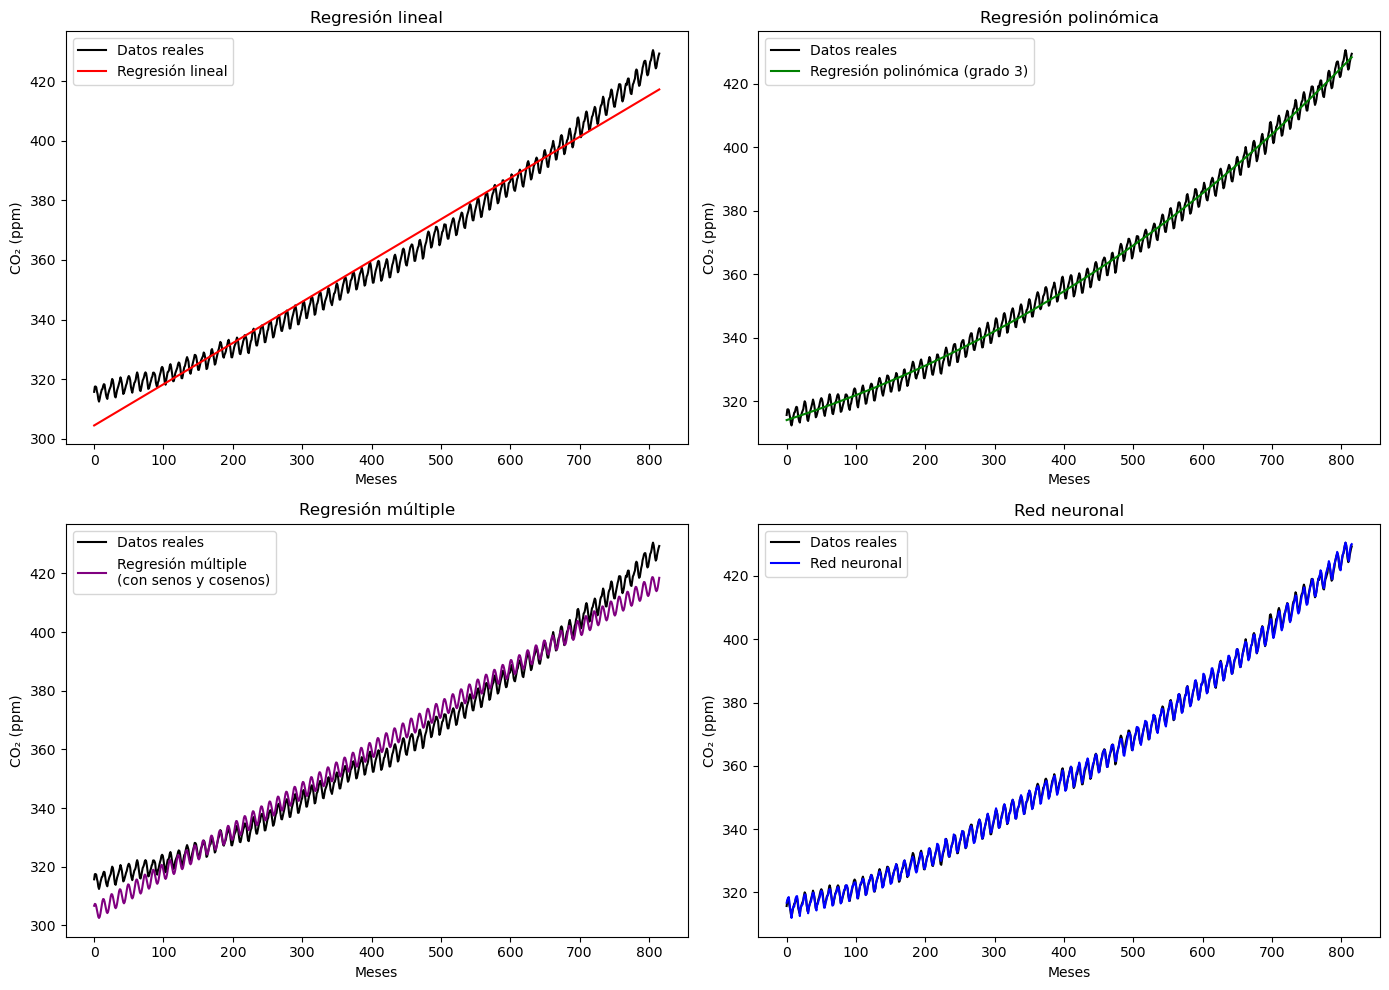

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.neural_network import MLPRegressor

# -----------------------------
# Cargar datos reales: CO₂ mensual Mauna Loa
url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv"
df = pd.read_csv(url, comment='#', header=None, usecols=[3], names=['CO2'])

# Convertir a numérico y eliminar valores faltantes
data = pd.to_numeric(df['CO2'], errors='coerce').dropna().values
t = np.arange(len(data)).reshape(-1,1)

# -----------------------------
# Regresión lineal
model_lin = LinearRegression()
model_lin.fit(t, data)
y_pred_lin = model_lin.predict(t)

# -----------------------------
# Regresión polinómica (grado 3)
poly = PolynomialFeatures(degree=3)
t_poly = poly.fit_transform(t)
model_poly = LinearRegression()
model_poly.fit(t_poly, data)
y_pred_poly = model_poly.predict(t_poly)

# -----------------------------
# Regresión múltiple: añadimos senos y cosenos
X_multi = np.hstack([
    t,
    np.sin(2 * np.pi * t / 12),
    np.cos(2 * np.pi * t / 12)
])
model_multi = LinearRegression()
model_multi.fit(X_multi, data)
y_pred_multi = model_multi.predict(X_multi)

# -----------------------------
# Red neuronal
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_multi)
nn = MLPRegressor(hidden_layer_sizes=(64,64), activation='relu', max_iter=5000, random_state=0)
nn.fit(X_scaled, data)
y_pred_nn = nn.predict(X_scaled)

# -----------------------------
# Visualización en arreglo 2×2
fig, axs = plt.subplots(2, 2, figsize=(14,10))

axs[0,0].plot(t, data, label='Datos reales', color='black')
axs[0,0].plot(t, y_pred_lin, label='Regresión lineal', color='red')
axs[0,0].set_title('Regresión lineal')
axs[0,0].set_xlabel('Meses')
axs[0,0].set_ylabel('CO₂ (ppm)')
axs[0,0].legend()

axs[0,1].plot(t, data, label='Datos reales', color='black')
axs[0,1].plot(t, y_pred_poly, label='Regresión polinómica (grado 3)', color='green')
axs[0,1].set_title('Regresión polinómica')
axs[0,1].set_xlabel('Meses')
axs[0,1].set_ylabel('CO₂ (ppm)')
axs[0,1].legend()

axs[1,0].plot(t, data, label='Datos reales', color='black')
axs[1,0].plot(t, y_pred_multi, label='Regresión múltiple\n(con senos y cosenos)', color='purple')
axs[1,0].set_title('Regresión múltiple')
axs[1,0].set_xlabel('Meses')
axs[1,0].set_ylabel('CO₂ (ppm)')
axs[1,0].legend()

axs[1,1].plot(t, data, label='Datos reales', color='black')
axs[1,1].plot(t, y_pred_nn, label='Red neuronal', color='blue')
axs[1,1].set_title('Red neuronal')
axs[1,1].set_xlabel('Meses')
axs[1,1].set_ylabel('CO₂ (ppm)')
axs[1,1].legend()

plt.tight_layout()
plt.show()


## **Clasificación** multiclase

**Breve descripción de la base de datos**  
El dataset **Wine Quality** (UCI Machine Learning Repository) contiene datos de vinos tintos producidos en la región del Valle del Duero (Portugal).

Cada muestra de vino se describe mediante **11 atributos fisicoquímicos** (como acidez, pH, azúcar residual, sulfatos, densidad, entre otros).

La **variable objetivo** es la *calidad del vino*, un número entero que suele ir de 3 a 8, evaluado por expertos catadores.  

Se trata de un problema de **clasificación multiclase**, en el que la red neuronal aprende a predecir la calidad del vino a partir de sus características químicas.


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Paso 1: Cargar datos reales
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print("Primeras filas del dataset:")
print(df.head())

Primeras filas del dataset:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8    

In [6]:
# Paso 2: Preprocesamiento
X = df.drop('quality', axis=1).values
y = df['quality'].values

# Normalización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Paso 3: Construir red neuronal
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

# Paso 4: Entrenar
mlp.fit(X_train, y_train)

# Paso 5: Evaluar
y_pred = mlp.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nExactitud en datos de prueba: {accuracy:.2f}")

# Mostrar las clases que el modelo está aprendiendo a clasificar
print("\nClases encontradas en el dataset (calidades de vino):", np.unique(y))


Exactitud en datos de prueba: 0.65

Clases encontradas en el dataset (calidades de vino): [3 4 5 6 7 8]


C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


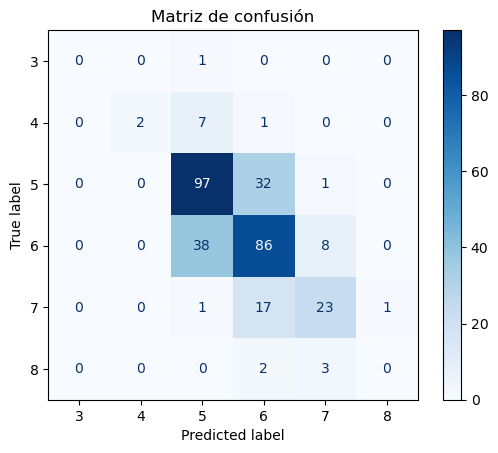

In [7]:
# Paso 6: Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mlp.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusión")
plt.show()

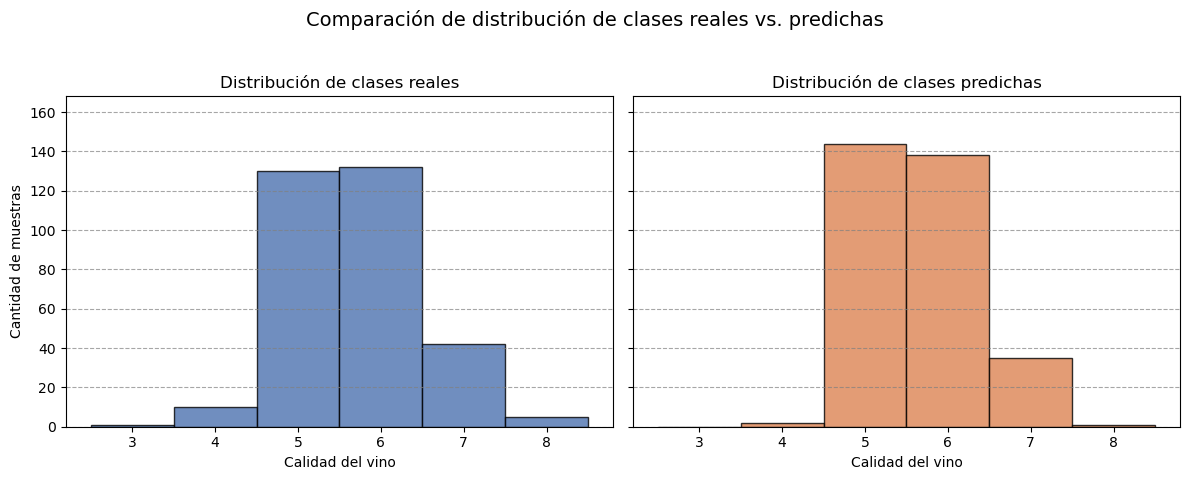

In [8]:
# Paso 7: Visualizar distribución de clases reales vs. predichas en subplots
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

bins = np.arange(min(y_test.min(), y_pred.min())-0.5, max(y_test.max(), y_pred.max())+1, 1)

# Subplot para clases reales
axes[0].hist(y_test, bins=bins, color='#4C72B0', alpha=0.8, edgecolor='black')
axes[0].set_title('Distribución de clases reales')
axes[0].set_xlabel('Calidad del vino')
axes[0].set_ylabel('Cantidad de muestras')

# Subplot para clases predichas
axes[1].hist(y_pred, bins=bins, color='#DD8452', alpha=0.8, edgecolor='black')
axes[1].set_title('Distribución de clases predichas')
axes[1].set_xlabel('Calidad del vino')

# Añadir líneas horizontales punteadas cada 20 unidades
max_count = max(axes[0].patches + axes[1].patches, key=lambda p: p.get_height()).get_height()
yticks = np.arange(0, max_count + 20, 20)

for y in yticks:
    axes[0].axhline(y, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
    axes[1].axhline(y, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)

plt.suptitle('Comparación de distribución de clases reales vs. predichas', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



Ejemplos de predicciones:
Muestra 213: calidad real=6, predicha=6
Muestra 130: calidad real=6, predicha=6
Muestra 296: calidad real=5, predicha=5
Muestra 230: calidad real=5, predicha=5
Muestra 171: calidad real=5, predicha=5
Muestra 15: calidad real=7, predicha=7
Muestra 162: calidad real=7, predicha=6
Muestra 227: calidad real=7, predicha=7
Muestra 62: calidad real=5, predicha=5
Muestra 96: calidad real=5, predicha=5


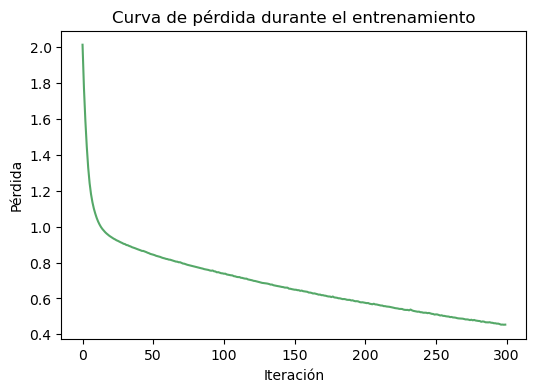

In [9]:
# Paso 8: Mostrar algunas predicciones concretas
print("\nEjemplos de predicciones:")
example_indices = np.random.choice(len(X_test), size=10, replace=False)
for idx in example_indices:
    print(f"Muestra {idx}: calidad real={y_test[idx]}, predicha={y_pred[idx]}")

# Paso 9 (opcional): Curva de pérdida
plt.figure(figsize=(6,4))
plt.plot(mlp.loss_curve_, color='#55A868')
plt.title('Curva de pérdida durante el entrenamiento')
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.show()

## Ejemplo con imágenes de dígitos

The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples.

Four files are available:

- `train-images-idx3-ubyte.gz`: training set images (9,912,422 bytes)
- `train-labels-idx1-ubyte.gz`: training set labels (28,881 bytes)
- `t10k-images-idx3-ubyte.gz`: test set images (1,648,877 bytes)
- `t10k-labels-idx1-ubyte.gz`: test set labels (4,542 bytes)/s (4542 bytes)

<img src="./fig/Notebook/MNIST_dataset_example.png">
<caption><left> Fig. Muestra MNIST </left></caption>

In [10]:
from get_images import get_images # get_images es una función que se creó y está en la carpeta donde se corre el código

In [11]:
### Importar MNIST 
# MNIST path
#mnist_path = './mnist_raw/'
mnist_path = './NMIST_Database/'

In [12]:
# Leer los datos

x_train_num, y_train_num, x_test_num, y_test_num = get_images(mnist_path)

print('tamaño x train: ', x_train_num.shape)
print('tamaño y train: ', y_train_num.shape)
print('tamaño x test: ', x_test_num.shape)
print('tamaño y test: ', y_test_num.shape)

tamaño x train:  (60000, 28, 28)
tamaño y train:  (60000,)
tamaño x test:  (10000, 28, 28)
tamaño y test:  (10000,)


In [13]:
### Convertir imágenes en vectores, y a float32

# PRIMERO LOS DATOS DE ENTRENAMIENTO
# Aplanar imágenes (de 28x28 a vectores de 784)
x_train = x_train_num.reshape(60000, -1).astype(np.float32)
x_test = x_test_num.reshape(10000, -1).astype(np.float32)

# Normalizar a [0, 1]
x_train /= 255.0
x_test /= 255.0

# LUEGO LOS DATOS DE PRUEBA
# Función One-hot encoding con NumPy puro
def one_hot_encode(y, num_classes=10):
    one_hot = np.zeros((y.shape[0], num_classes))
    one_hot[np.arange(y.shape[0]), y] = 1
    return one_hot

y_train = one_hot_encode(y_train_num)
y_test = one_hot_encode(y_test_num)

# Ahora x_train tiene shape (60000, 784) y y_train tiene shape (60000, 10)
# Ahora x_test tiene shape (10000, 784) y y_test tiene shape (10000, 10)

print('tamaño x train: ', x_train.shape)
print('tamaño x test: ', x_test.shape)
print('tamaño y train: ', y_train.shape)
print('tamaño y test: ', y_test.shape)


tamaño x train:  (60000, 784)
tamaño x test:  (10000, 784)
tamaño y train:  (60000, 10)
tamaño y test:  (10000, 10)


In [14]:
## Graficar algunas imágenes

def plot_number(image):
    plt.imshow(image.squeeze(), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

La imagen muestreada representa un: 5


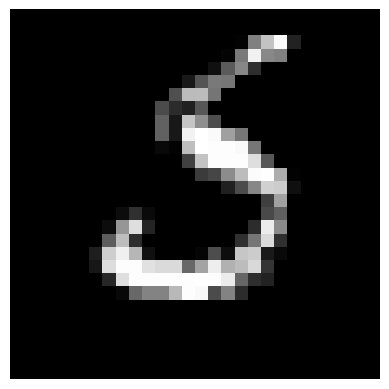

In [15]:
rnd_idx = np.random.randint(len(y_test))
print(f'La imagen muestreada representa un: {y_test_num[rnd_idx]}')
plot_number(x_test_num[rnd_idx])

### Dividir los datos

#### Los tres grupos de datos en Machine Learning
##### 1. Conjunto de **entrenamiento** (`train`)
- Uso: Se utiliza para **ajustar los parámetros del modelo** (pesos, sesgos, etc.).
- El modelo **ve estos datos muchas veces** durante el entrenamiento.
- Se usa directamente para **minimizar la función de pérdida**.

Es el único conjunto que el modelo realmente "aprende".

##### 2. Conjunto de **validación** (`val`)
- Uso: Se utiliza para **monitorear el rendimiento del modelo** mientras se entrena.
- Ayuda a:
  - Ver si el modelo está sobreajustando (overfitting)
  - Elegir hiperparámetros (número de capas, tasa de aprendizaje, etc.)
  - Activar **early stopping** si la validación deja de mejorar
- El modelo **no entrena con estos datos**, solo los evalúa.

##### 3. Conjunto de **prueba** (`test`)
- Uso: Se utiliza **al final del entrenamiento**, una sola vez, para **medir el rendimiento final** del modelo.
- Nunca se usa durante el entrenamiento ni en la validación.

### Resumen visual:

| Grupo       | ¿El modelo lo ve durante entrenamiento? | ¿Se usa para ajustar pesos? | ¿Se usa para medir rendimiento? |
|-------------|------------------------------------------|-----------------------------|---------------------------------|
| `train`     | ✅ Sí                                     | ✅ Sí                        | ✅ Sí (en cada época)           |
| `val`       | ⚠️ Sí (solo para evaluar)                 | ❌ No                        | ✅ Sí (en validaciones)         |
| `test`      | ❌ No                                     | ❌ No                        | ✅ Sí (al final)                |

In [16]:
x_train_part = x_train[:50000]
y_train_part = y_train[:50000]

x_val = x_train[50000:]
y_val = y_train[50000:]

print('tamaño x train part: ', x_train_part.shape)
print('tamaño x val: ', x_val.shape)
print('tamaño y train: ', y_train_part.shape)
print('tamaño y val: ', y_val.shape)

tamaño x train part:  (50000, 784)
tamaño x val:  (10000, 784)
tamaño y train:  (50000, 10)
tamaño y val:  (10000, 10)


In [17]:
def init_network(layer_sizes, activations):
    assert len(layer_sizes) - 2 == len(activations), "El tamaño del vector de **activations** deben coincidir con el número de capas ocultas"
    params = []
    for i in range(len(layer_sizes) - 1):
        W = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * np.sqrt(2. / layer_sizes[i]) # Inicializaciónde He para los pesos 
        b = np.zeros((1, layer_sizes[i+1])) # Inicializacion de los sesgos
        params.append({"W": W, "b": b})
    return {
        "layer_sizes": layer_sizes,
        "activations": activations,
        "params": params,
        "loss_history": [],
        "acc_history": []
    }

In [18]:
def train(network, X, y, X_val=None, y_val=None, epochs=1000, lr=0.01, batch_size=32, verbose=True):
    network["loss_history"] = []
    network["acc_history"] = []
    print_interval = max(1, epochs // 10)

    for epoch in range(1, epochs + 1):
        for X_batch, y_batch in crear_batches(X, y, batch_size):
            y_hat, caches = forward(network, X_batch)
            grads = backward(network, X_batch, y_batch, caches)
            update_params(network, grads, lr)

        loss, acc = evaluar_modelo(network, X, y)
        network["loss_history"].append(loss)
        network["acc_history"].append(acc)

        if verbose and (epoch % print_interval == 0 or epoch == epochs):
            print(f"Epoch {epoch}/{epochs}: loss = {loss:.4f}, accuracy = {acc:.4f}")
            
            # Si se pasan datos de validación, evaluarlos también
            if X_val is not None and y_val is not None:
                val_loss, val_acc = evaluar_modelo(net, X_val, y_val)
                print(f"  Val   Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

In [19]:
def crear_batches(X, y, batch_size):
    m = X.shape[0]
    indices = np.random.permutation(m)
    X_shuffled = X[indices]
    y_shuffled = y[indices]
    for i in range(0, m, batch_size):
        yield X_shuffled[i:i+batch_size], y_shuffled[i:i+batch_size]

In [20]:
def forward(network, X):
    a = X
    caches = [{"A": a}]
    for i, layer in enumerate(network["params"][:-1]):
        z = np.dot(a, layer["W"]) + layer["b"]
        act_fn, _ = activation_funcs[network["activations"][i]]
        a = act_fn(z)
        caches.append({"Z": z, "A": a})
    z = np.dot(a, network["params"][-1]["W"]) + network["params"][-1]["b"]
    a = softmax(z)
    caches.append({"Z": z, "A": a})
    return a, caches

In [21]:
# Funciones de activación y sus derivadas

# Parámetros estándar para SELU
lambda_selu = 1.0507
alpha_selu = 1.6733


activation_funcs = {
    "relu": (
        lambda x: np.maximum(0, x), # Función de activación
        lambda x: (x > 0).astype(float) # Derivada
    ),
    "tanh": (
        np.tanh,  # Función de activación
        lambda x: 1 - np.tanh(x)**2 # Derivada
    ),
    "sigmoid": (
        lambda x: 1 / (1 + np.exp(-x)), # Función de activación
        lambda x: (1 / (1 + np.exp(-x))) * (1 - 1 / (1 + np.exp(-x))) # Derivada
    ),
    "linear": (
        lambda x: x,  # Función de activación
        lambda x: np.ones_like(x)  # Derivada
    ),
    "selu": (
        lambda x: lambda_selu * np.where(x > 0, x, alpha_selu * (np.exp(x) - 1)),
        lambda x: lambda_selu * np.where(x > 0, 1, alpha_selu * np.exp(x))
    )
}



# Función softmax
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


In [22]:
def backward(network, X, y, caches):
    grads = []
    m = X.shape[0] # Número de muestras en el conjunto de datos (tamaño del minibatch).
    y_hat = caches[-1]["A"] # La salida de la red neuronal para las entradas proporcionadas `X`(forward pass).
    delta = y_hat - y  # Ecuación: $\delta^{[L]} = \hat{y} - y$
    L = len(network["params"])
    for l in reversed(range(L)):
        A_prev = caches[l]["A"]
        Z = caches[l+1]["Z"]
        dW = np.dot(A_prev.T, delta) / m # gradientes con respecto a los pesos `W` en la última capa.
        db = np.sum(delta, axis=0, keepdims=True) / m # gradientes con respecto a los sesgos `b` de la última capa.
        grads.insert(0, {"dW": dW, "db": db})
        if l > 0: # delta: El nuevo error se calcula multiplicando el error anterior por la transpuesta de los pesos de la capa actual W,
                    # y luego se ajusta con la derivada de la función de activación (dact).
            _, dact = activation_funcs[network["activations"][l-1]]
            delta = np.dot(delta, network["params"][l]["W"].T) * dact(caches[l]["Z"])
    return grads

In [23]:
def update_params(network, grads, lr):
    for i in range(len(network["params"])):
        network["params"][i]["W"] -= lr * grads[i]["dW"]
        network["params"][i]["b"] -= lr * grads[i]["db"]

In [24]:
def evaluar_modelo(network, X, y):
    y_pred, _ = forward(network, X)
    loss = -np.mean(np.sum(y * np.log(y_pred + 1e-8), axis=1))
    acc = np.mean(np.argmax(y_pred, axis=1) == np.argmax(y, axis=1))
    return loss, acc

In [25]:
def save_params(network, filename_prefix="model"):
    for i, layer in enumerate(network["params"]):
        np.save(f"{filename_prefix}_W{i}.npy", layer["W"])
        np.save(f"{filename_prefix}_b{i}.npy", layer["b"])

In [26]:
def plot_history(network):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(network["loss_history"])
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(network["acc_history"])
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")

    plt.tight_layout()
    plt.show()

In [27]:
def load_params(network, filename_prefix="model"):
    for i in range(len(network["params"])):
        network["params"][i]["W"] = np.load(f"{filename_prefix}_W{i}.npy")
        network["params"][i]["b"] = np.load(f"{filename_prefix}_b{i}.npy")

In [28]:
def predict(network, X):
    y_hat, _ = forward(network, X)
    return np.argmax(y_hat, axis=1)

In [29]:
# Inicializar y entrenar red

layer_sizes = [784, 200, 100, 10] ## Esta lista define el tamaño de cada capa de la red neuronal.
activations = ["relu","relu"] ## Esta lista especifica las funciones de activación a usar en las capas ocultas de la red.
net = init_network(layer_sizes, activations) ## Inicializa la red neuronal con las especificaciones proporcionadas

## Entrenamiento de la red

- Se entrena la red neuronal `net` utilizando los siguientes conjuntos y parámetros:

### Datos utilizados

- `x_train_part`, `y_train_part`: conjunto de **entrenamiento** (por ejemplo, 50,000 muestras).
- `x_val`, `y_val`: conjunto de **validación** (por ejemplo, 10,000 muestras), usado para monitorear el rendimiento del modelo en datos no vistos.

### Parámetros del entrenamiento

- `epochs=20`: el modelo pasará **20 veces** por todos los datos de entrenamiento.
- `lr=0.05`: **tasa de aprendizaje** (*learning rate*), controla qué tan grandes son los pasos de ajuste de los pesos.
- `batch_size=64`: el entrenamiento se realiza en **mini-lotes** de 64 muestras.
- `verbose=True`: imprime el progreso del entrenamiento (pérdida y exactitud cada cierto número de épocas).

Epoch 2/20: loss = 0.3314, accuracy = 0.9057
  Val   Loss: 0.3051, Accuracy: 0.9135
Epoch 4/20: loss = 0.2568, accuracy = 0.9278
  Val   Loss: 0.2432, Accuracy: 0.9303
Epoch 6/20: loss = 0.2136, accuracy = 0.9391
  Val   Loss: 0.2049, Accuracy: 0.9435
Epoch 8/20: loss = 0.1912, accuracy = 0.9458
  Val   Loss: 0.1889, Accuracy: 0.9482
Epoch 10/20: loss = 0.1683, accuracy = 0.9517
  Val   Loss: 0.1695, Accuracy: 0.9520
Epoch 12/20: loss = 0.1482, accuracy = 0.9574
  Val   Loss: 0.1530, Accuracy: 0.9581
Epoch 14/20: loss = 0.1318, accuracy = 0.9630
  Val   Loss: 0.1396, Accuracy: 0.9620
Epoch 16/20: loss = 0.1181, accuracy = 0.9666
  Val   Loss: 0.1297, Accuracy: 0.9641
Epoch 18/20: loss = 0.1074, accuracy = 0.9702
  Val   Loss: 0.1216, Accuracy: 0.9665
Epoch 20/20: loss = 0.1010, accuracy = 0.9719
  Val   Loss: 0.1183, Accuracy: 0.9660
Test Loss: 0.1196, Test Accuracy: 0.9648


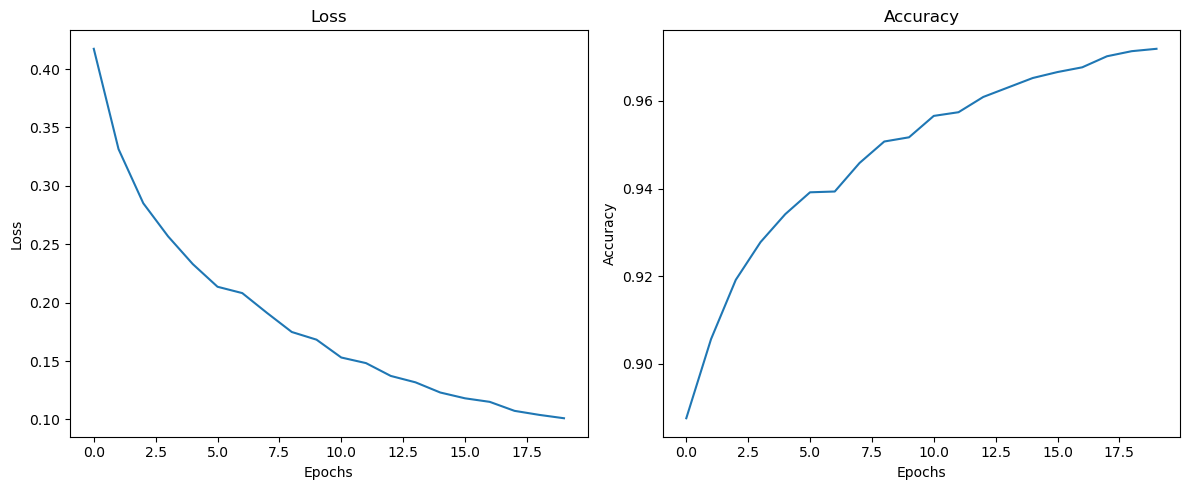

In [30]:
train(net, x_train_part, y_train_part, x_val, y_val, epochs=20, lr=1e-2, batch_size=64, verbose=True)

# Evaluar
loss, acc = evaluar_modelo(net, x_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")

# Visualizar
plot_history(net)

# Guardar modelo
save_params(net, "./Parametros/modelo_final_MNIST")

### Cargar modelo y predecir

In [31]:
# Cargar modelo de la red y predecir
net_loaded = init_network(layer_sizes, activations)
load_params(net_loaded, "./Parametros/modelo_final_MNIST")

preds = predict(net_loaded, x_test)
true = np.argmax(y_test, axis=1)
acc_loaded = np.mean(preds == true)
print(f"Accuracy red cargada: {acc_loaded:.4f}")


Accuracy red cargada: 0.9648


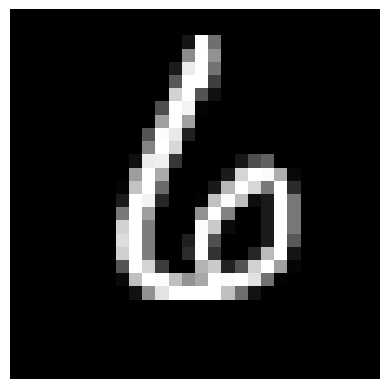

el valor predicho es: [6]


In [32]:
#Visualizar
idx = np.random.randint(len(y_test))
plot_number(x_test_num[idx])
pred = predict(net_loaded, x_test[idx])
print(f'el valor predicho es: {pred}')

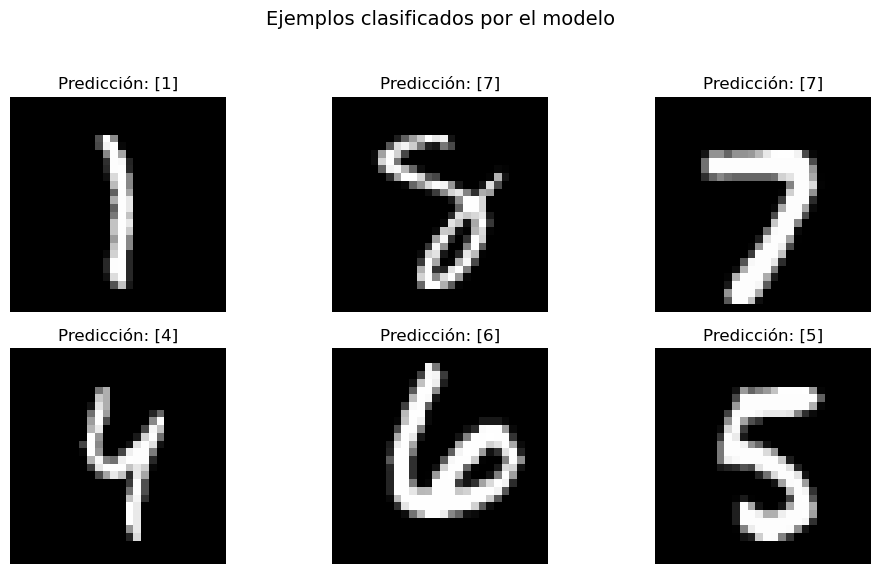

In [33]:
# Elegir 6 índices aleatorios sin repetición
sample_indices = np.random.choice(len(y_test), size=6, replace=False)

# Crear figura 2x3
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

for idx, ax in zip(sample_indices, axes.ravel()):
    # Obtener imagen
    img = x_test_num[idx]
    
    # Predecir
    pred = predict(net_loaded, x_test[idx])
    
    # Mostrar imagen (ajusta reshape si es necesario, ej: img.reshape(28,28))
    ax.imshow(img.reshape(28,28), cmap='gray')
    
    # Título con valor predicho
    ax.set_title(f'Predicción: {pred}')
    
    # Quitar ejes para mayor claridad
    ax.axis('off')

plt.suptitle('Ejemplos clasificados por el modelo', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Generación de Datos

### Base de datos ECG200

La base de datos `ECG200` proviene del *UCR Time Series Classification Archive* y contiene:

- **200 señales reales** de electrocardiograma (ECG).
- Cada señal tiene una longitud fija de **96 muestras**.
- Las señales están etiquetadas como **normal** o **anormal** (aunque en este ejemplo solo usamos las señales, no las etiquetas).
- Cada muestra representa la amplitud del ECG en un instante, por lo que al graficarlas se observan las oscilaciones típicas de los electrocardiogramas.

Estas características hacen que sea un conjunto de datos muy utilizado para experimentar con modelos de clasificación, generación de series temporales y análisis de patrones en datos biomédicos.

In [34]:
#!pip install tslearn

Datos cargados: 100 señales de entrenamiento, longitud 96


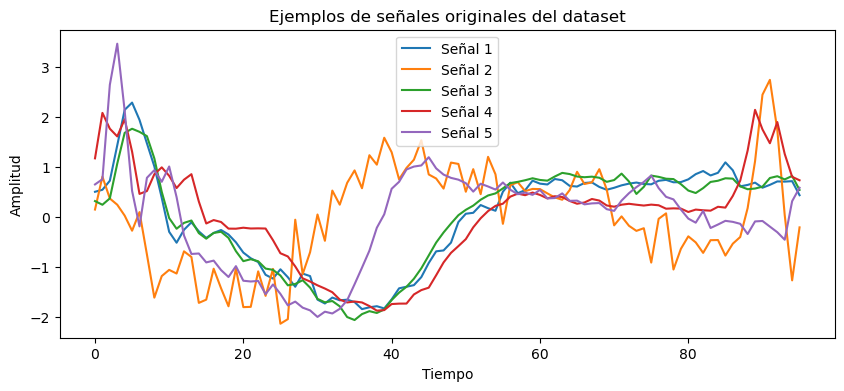

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from tslearn.datasets import UCR_UEA_datasets
from sklearn.neural_network import MLPRegressor

# Paso 1: Cargar datos reales de base de datos (ECG200)
loader = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = loader.load_dataset("ECG200")

print(f"Datos cargados: {X_train.shape[0]} señales de entrenamiento, longitud {X_train.shape[1]}")

# Paso 2: Mostrar algunas señales originales
plt.figure(figsize=(10,4))
for i in range(5):
    plt.plot(X_train[i].ravel(), label=f'Señal {i+1}')
plt.title('Ejemplos de señales originales del dataset')
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.legend()
plt.show()

Entrenando red neuronal...


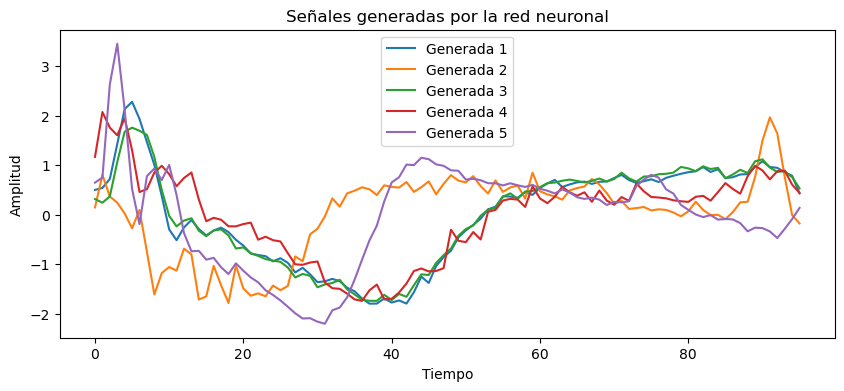

In [36]:
# Paso 3: Preparar datos para entrenamiento
# Queremos entrenar un modelo que dado el inicio de la señal prediga el resto
n_input = 20
n_output = X_train.shape[1] - n_input

X = []
y = []
for signal in X_train:
    signal = signal.ravel()
    X.append(signal[:n_input])
    y.append(signal[n_input:])

X = np.array(X)
y = np.array(y)

# Paso 4: Entrenar red neuronal
print("Entrenando red neuronal...")
mlp = MLPRegressor(hidden_layer_sizes=(64, 64), activation='tanh', solver='adam', max_iter=500, random_state=42)
mlp.fit(X, y)

# Paso 5: Generar nuevas señales
generated_signals = []
for i in range(5):  # generamos 5 nuevas
    seed = X_train[i, :n_input].ravel().reshape(1, -1)  # usamos el mismo inicio
    generated_part = mlp.predict(seed)[0]
    generated_signal = np.concatenate([seed.ravel(), generated_part])
    generated_signals.append(generated_signal)

# Paso 6: Mostrar señales generadas
plt.figure(figsize=(10,4))
for i, gen_sig in enumerate(generated_signals):
    plt.plot(gen_sig, label=f'Generada {i+1}')
plt.title('Señales generadas por la red neuronal')
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.legend()
plt.show()

### Generación de dígitos del 0 al 9 usando una red neuronal

Este código utiliza el conjunto de datos real **MNIST**, que contiene imágenes de dígitos escritos a mano (0–9).  
Los pasos principales son:

- Se selecciona un ejemplo real de cada dígito del 0 al 9.
- Se entrena una red neuronal tipo *autoencoder* (`MLPRegressor`) para aprender a reconstruir imágenes a partir de sí mismas.
- Se generan nuevas imágenes pasando los dígitos reales por la red, obteniendo su versión reconstruida o generada.
- Finalmente, se muestran juntos los ejemplos originales y las imágenes generadas para comparar los resultados.

Este ejemplo permite visualizar cómo una red neuronal puede aprender patrones básicos de las imágenes reales y generar nuevas que imiten su apariencia.

> **Nota:** Esto NO es un generador profundo (como un GAN).


Descargando MNIST...
Datos cargados: 70000 imágenes de tamaño 28x28
Entrenando red neuronal para reconstruir imágenes...


C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


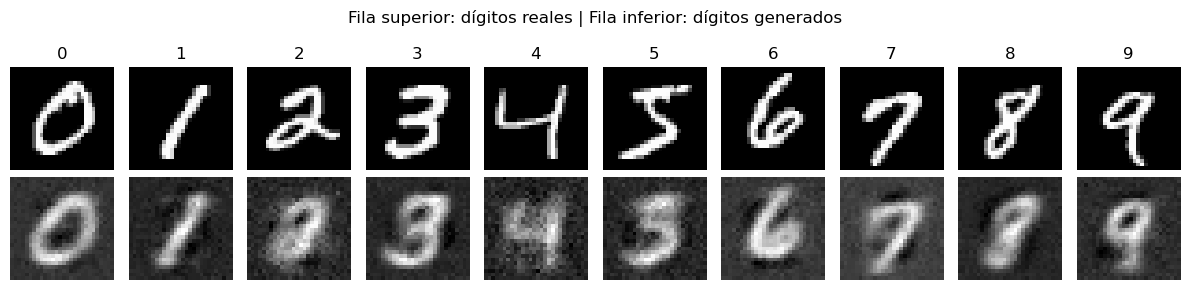

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPRegressor

# Paso 1: Cargar base de datos MNIST
print("Descargando MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data / 255.0  # normalizamos entre 0 y 1
y = mnist.target.astype(int)

print(f"Datos cargados: {X.shape[0]} imágenes de tamaño 28x28")

# Paso 2: Seleccionar un ejemplo de cada dígito 0–9
sample_indices = []
for digit in range(10):
    idx = np.where(y == digit)[0][0]
    sample_indices.append(idx)

X_samples = X[sample_indices]
y_samples = y[sample_indices]

# Paso 3: Entrenar red neuronal (autoencoder simple)
print("Entrenando red neuronal para reconstruir imágenes...")
mlp = MLPRegressor(hidden_layer_sizes=(128, 64, 128), activation='relu', solver='adam', max_iter=10, random_state=42)
mlp.fit(X[:2000], X[:2000])  # solo con 2000 imágenes para que sea rápido

# Paso 4: Generar imágenes (reconstruir)
generated = mlp.predict(X_samples)

# Paso 5: Visualizar en dos filas
plt.figure(figsize=(12, 3))
for i in range(10):
    # Fila 1: imágenes reales
    plt.subplot(2, 10, i+1)
    plt.imshow(X_samples[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    plt.title(f'{y_samples[i]}')
    
    # Fila 2: imágenes generadas
    plt.subplot(2, 10, i+11)
    plt.imshow(generated[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.suptitle('Fila superior: dígitos reales | Fila inferior: dígitos generados')
plt.tight_layout()
plt.show()


## Interpolación

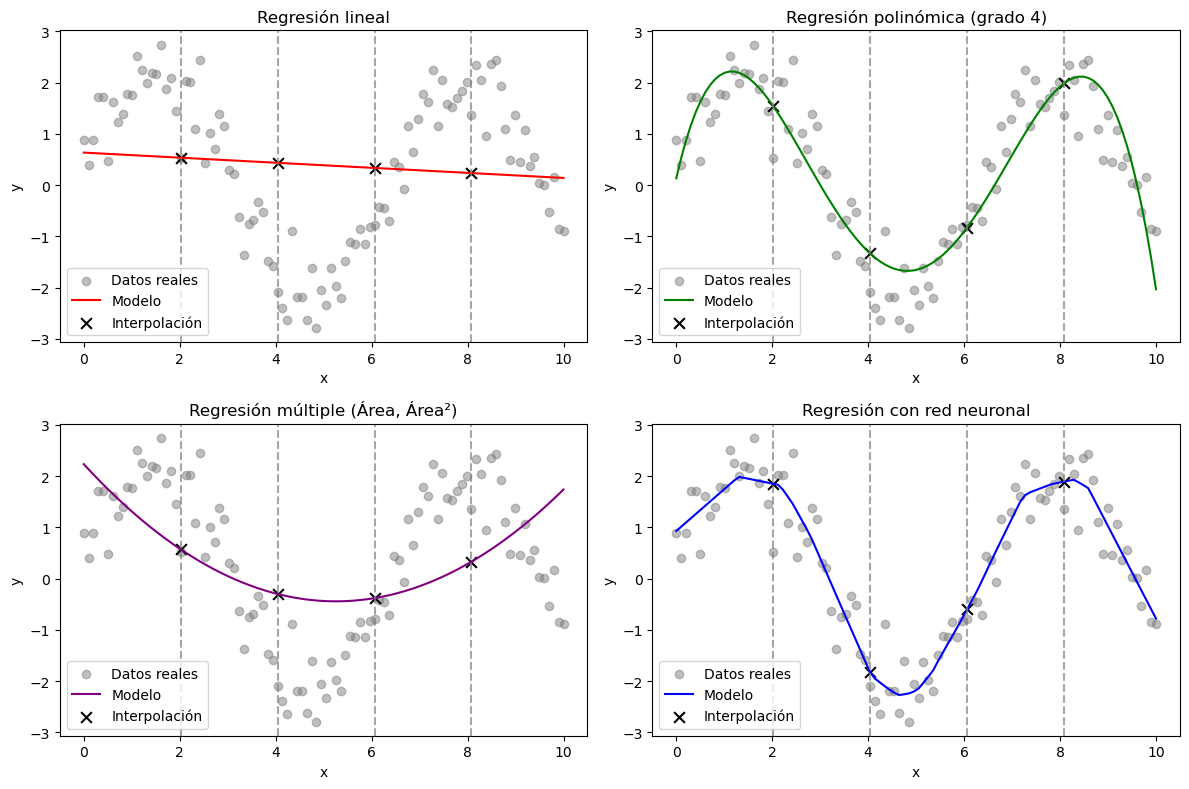

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.neural_network import MLPRegressor

# -----------------------------
# Datos sintéticos
np.random.seed(0)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 2 * np.sin(X).ravel() + np.random.normal(scale=0.5, size=100)

# -----------------------------
# Elegir algunos puntos intermedios (puntos de interpolación)
interp_idx = [20, 40, 60, 80]  # índices dentro del rango
X_interp = X[interp_idx]
y_interp = y[interp_idx]

# -----------------------------
# Regresión lineal
model_linear = LinearRegression()
model_linear.fit(X, y)

# -----------------------------
# Regresión polinómica (grado 4)
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)
model_poly = LinearRegression()
model_poly.fit(X_poly, y)

# -----------------------------
# Regresión múltiple (Área y Área^2)
X_multi = np.hstack((X, X**2))
model_multi = LinearRegression()
model_multi.fit(X_multi, y)

# -----------------------------
# Red neuronal
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

nn = MLPRegressor(hidden_layer_sizes=(64,64,64), activation='relu', max_iter=2000, random_state=0)
nn.fit(X_scaled, y)

# Predicciones en todo el rango
y_linear_pred = model_linear.predict(X)
y_poly_pred = model_poly.predict(X_poly)
y_multi_pred = model_multi.predict(X_multi)
y_nn_pred = nn.predict(X_scaled)

# Predicciones en los puntos de interpolación
X_interp_poly = poly.transform(X_interp)
X_interp_multi = np.hstack((X_interp, X_interp**2))
X_interp_scaled = scaler.transform(X_interp)

y_interp_linear = model_linear.predict(X_interp)
y_interp_poly = model_poly.predict(X_interp_poly)
y_interp_multi = model_multi.predict(X_interp_multi)
y_interp_nn = nn.predict(X_interp_scaled)

# -----------------------------
# Visualización
plt.figure(figsize=(12, 8))

for idx, (title, y_pred, y_interp_pred) in enumerate([
    ('Regresión lineal', y_linear_pred, y_interp_linear),
    ('Regresión polinómica (grado 4)', y_poly_pred, y_interp_poly),
    ('Regresión múltiple (Área, Área²)', y_multi_pred, y_interp_multi),
    ('Regresión con red neuronal', y_nn_pred, y_interp_nn)
]):
    ax = plt.subplot(2, 2, idx+1)
    ax.scatter(X, y, color='gray', alpha=0.5, label='Datos reales')
    ax.plot(X, y_pred, label='Modelo', color=['red','green','purple','blue'][idx])
    ax.scatter(X_interp, y_interp_pred, color='black', marker='x', s=60, label='Interpolación')
    
    # Dibujar líneas verticales en los puntos de interpolación
    for xi in X_interp:
        ax.axvline(x=xi, color='gray', linestyle='--', alpha=0.7)
    
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()

plt.tight_layout()
plt.show()

### Datos reales: Auto MPG

En este ejemplo se utiliza el conjunto de datos real **Auto MPG** incluido en la librería `seaborn`.  
Este dataset contiene información de automóviles fabricados entre 1970 y 1980 y se usa frecuentemente para análisis de regresión.

Las principales características del dataset son:
- **mpg**: millas por galón, representa la eficiencia del consumo de combustible (*variable dependiente*).
- **horsepower**: potencia del motor, usada como variable independiente para predecir el consumo.

El objetivo del ejercicio es **interpolar** y ajustar distintos modelos para aproximar la relación (potencia → consumo) y comparar cómo cada modelo captura esta relación.


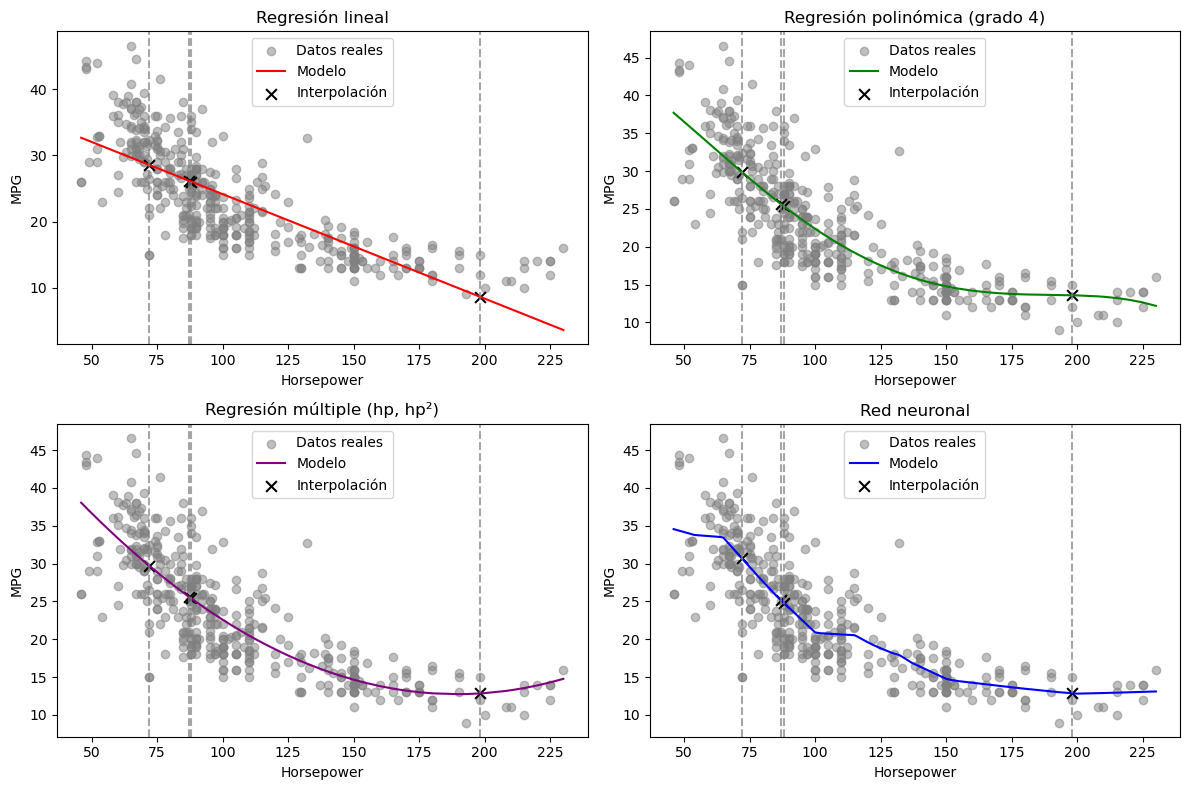

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.neural_network import MLPRegressor
import seaborn as sns

# -----------------------------
# Cargar datos reales: Auto MPG
df = sns.load_dataset('mpg').dropna()

# Variable independiente: horsepower
# Variable dependiente: mpg
X = df['horsepower'].values.reshape(-1,1)
y = df['mpg'].values

# -----------------------------
# Elegir algunos puntos intermedios (puntos de interpolación)
interp_idx = [5, 20, 35, 45]
X_interp = X[interp_idx]
y_interp = y[interp_idx]

# -----------------------------
# Regresión lineal
model_linear = LinearRegression()
model_linear.fit(X, y)

# -----------------------------
# Regresión polinómica (grado 4)
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)
model_poly = LinearRegression()
model_poly.fit(X_poly, y)

# -----------------------------
# Regresión múltiple (horsepower y horsepower²)
X_multi = np.hstack((X, X**2))
model_multi = LinearRegression()
model_multi.fit(X_multi, y)

# -----------------------------
# Red neuronal
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

nn = MLPRegressor(hidden_layer_sizes=(64,64,64), activation='relu', max_iter=2000, random_state=0)
nn.fit(X_scaled, y)

# Predicciones en todo el rango
y_linear_pred = model_linear.predict(X)
y_poly_pred = model_poly.predict(X_poly)
y_multi_pred = model_multi.predict(X_multi)
y_nn_pred = nn.predict(X_scaled)

# Predicciones en los puntos de interpolación
X_interp_poly = poly.transform(X_interp)
X_interp_multi = np.hstack((X_interp, X_interp**2))
X_interp_scaled = scaler.transform(X_interp)

y_interp_linear = model_linear.predict(X_interp)
y_interp_poly = model_poly.predict(X_interp_poly)
y_interp_multi = model_multi.predict(X_interp_multi)
y_interp_nn = nn.predict(X_interp_scaled)

# -----------------------------
# Visualización
plt.figure(figsize=(12, 8))

# Ordenar X y predicciones antes de graficar
order = np.argsort(X.ravel())
X_sorted = X.ravel()[order]

for idx, (title, y_pred, y_interp_pred) in enumerate([
    ('Regresión lineal', y_linear_pred, y_interp_linear),
    ('Regresión polinómica (grado 4)', y_poly_pred, y_interp_poly),
    ('Regresión múltiple (hp, hp²)', y_multi_pred, y_interp_multi),
    ('Red neuronal', y_nn_pred, y_interp_nn)
]):
    y_pred_sorted = y_pred[order]
    
    ax = plt.subplot(2, 2, idx+1)
    ax.scatter(X, y, color='gray', alpha=0.5, label='Datos reales')
    ax.plot(X_sorted, y_pred_sorted, color=['red','green','purple','blue'][idx], label='Modelo')
    ax.scatter(X_interp, y_interp_pred, color='black', marker='x', s=60, label='Interpolación')
    
    for xi in X_interp:
        ax.axvline(x=xi, color='gray', linestyle='--', alpha=0.7)
    
    ax.set_title(title)
    ax.set_xlabel('Horsepower')
    ax.set_ylabel('MPG')
    ax.legend()

plt.tight_layout()
plt.show()


## Segmentación

### Segmentación de una señal real con red neuronal

En este ejemplo se utiliza el conjunto de datos real **ECG200**, disponible en la colección *UCR/UEA Time Series Classification* (cargado con `tslearn`).  
Este dataset contiene señales reales de electrocardiogramas, cada una representando el ritmo cardíaco de un pacientsegún su contexto.


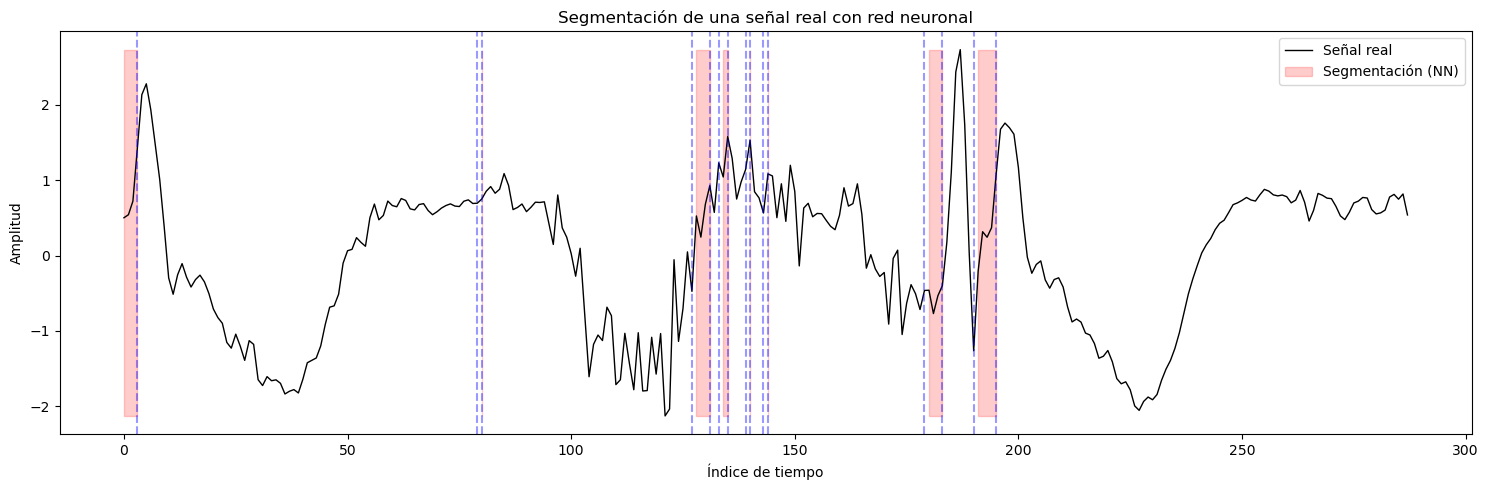

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from tslearn.datasets import UCR_UEA_datasets

# -----------------------------
# Cargar datos reales ECG200
ucr = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ucr.load_dataset('ECG200')

# Unimos para tener más señales
X_raw = np.concatenate([X_train, X_test])
y_raw = np.concatenate([y_train, y_test])

# -----------------------------
# Tomamos una señal más larga para ilustrar
# Por ejemplo, usar 3 señales concatenadas
signal = np.hstack([X_raw[0].ravel(), X_raw[1].ravel(), X_raw[2].ravel()])

# -----------------------------
# Generar etiquetas de segmentación (ejemplo didáctico):
# Segmentos donde la señal supera la media + std
threshold = np.mean(signal) + np.std(signal)
labels = (signal > threshold).astype(int)

# -----------------------------
# Ventanas de contexto
window_size = 5
X_features = []
y_target = []

for i in range(window_size, len(signal)-window_size):
    window = signal[i-window_size:i+window_size+1]
    X_features.append(window)
    y_target.append(labels[i])

X_features = np.array(X_features)
y_target = np.array(y_target)

# -----------------------------
# Dividir en train/test
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_features, y_target, test_size=0.2, random_state=0
)

# -----------------------------
# Red neuronal
clf = MLPClassifier(hidden_layer_sizes=(32,32), activation='relu', max_iter=1000, random_state=0)
clf.fit(X_train_f, y_train_f)

# -----------------------------
# Predicción en toda la señal
y_pred = clf.predict(X_features)

# -----------------------------
# Visualización mejorada
plt.figure(figsize=(15, 5))
plt.plot(signal, color='black', lw=1, label='Señal real')

# Relleno para los segmentos detectados
plt.fill_between(np.arange(len(y_pred)), signal.min(), signal.max(),
                 where=y_pred>0, color='red', alpha=0.2, label='Segmentación (NN)')

# Opcional: dibujar líneas verticales en los cambios de segmento detectados
change_points = np.where(np.diff(y_pred) != 0)[0]
for cp in change_points:
    plt.axvline(cp, color='blue', linestyle='--', alpha=0.4)

plt.title('Segmentación de una señal real con red neuronal')
plt.xlabel('Índice de tiempo')
plt.ylabel('Amplitud')
plt.legend()
plt.tight_layout()
plt.show()


### Segmentación de imágenes reales con red neuronal

En este ejemplo se utiliza el conjunto de datos **Olivetti Faces**, que contiene imágenes reales de caras humanas en escala de grises (tamaño 64×64 píxeles).  
Este dataset está disponible en `sklearn.datasets` y se compone de 400 imágenes de distintos sujetos.

> Este ejemplo ilustra la idea de la segmentación como **clasificación por píxel**, usando datos reales y una red neuronal sencilla, sin redes convolucionales.


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

# -----------------------------
# Cargar imágenes reales: caras Olivetti (grises, 64x64)
faces = fetch_olivetti_faces(shuffle=True, random_state=0)
images = faces.images  # shape (400, 64, 64)

# -----------------------------
# Creamos máscaras de segmentación: píxeles con intensidad > media global
mean_intensity = np.mean(images)
masks = (images > mean_intensity).astype(int)

# -----------------------------
# Preparamos datos para la red neuronal
X_features = []
y_labels = []

# Usamos solo las primeras 50 imágenes para ejemplo rápido
for img, mask in zip(images[:50], masks[:50]):
    X_features.extend(img.flatten().reshape(-1,1))   # característica = intensidad del píxel
    y_labels.extend(mask.flatten())

X_features = np.array(X_features)
y_labels = np.array(y_labels)

# -----------------------------
# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels, test_size=0.2, random_state=0
)

# -----------------------------
# Red neuronal
clf = MLPClassifier(hidden_layer_sizes=(64,32), activation='relu', max_iter=500, random_state=0)
clf.fit(X_train, y_train)

,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,0


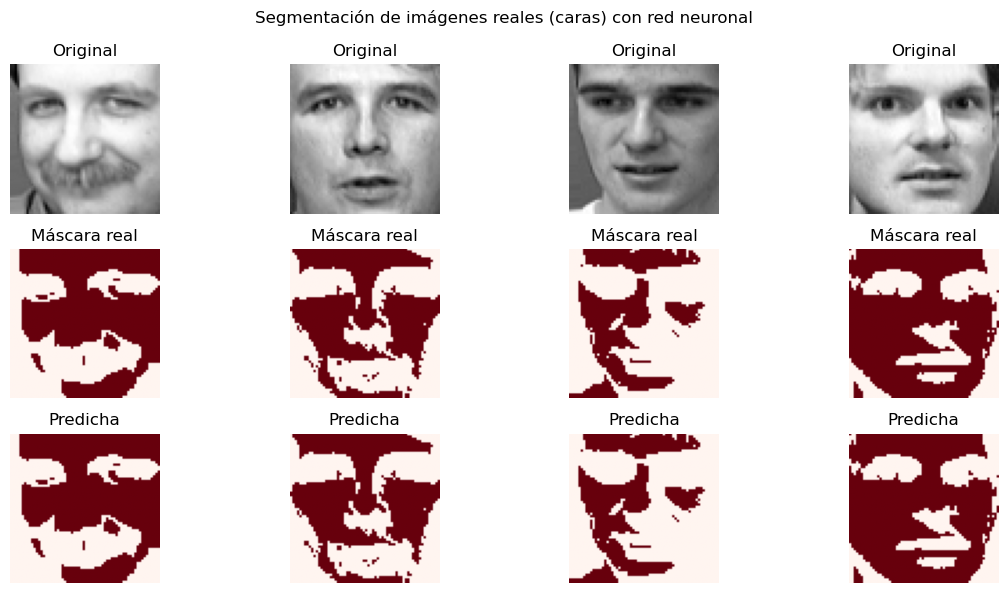

In [42]:
# -----------------------------
# Predicción en nuevas imágenes
test_images = images[50:54]
test_masks_true = (test_images > mean_intensity).astype(int)

predicted_masks = []
for img in test_images:
    pixels = img.flatten().reshape(-1,1)
    pred_mask = clf.predict(pixels)
    predicted_masks.append(pred_mask.reshape(img.shape))

# -----------------------------
# Visualización
n = len(test_images)
plt.figure(figsize=(12, 6))

for i in range(n):
    # Imagen original
    plt.subplot(3, n, i+1)
    plt.imshow(test_images[i], cmap='gray')
    plt.title('Original')
    plt.axis('off')
    
    # Máscara real
    plt.subplot(3, n, i+1+n)
    plt.imshow(test_masks_true[i], cmap='Reds')
    plt.title('Máscara real')
    plt.axis('off')
    
    # Máscara predicha
    plt.subplot(3, n, i+1+2*n)
    plt.imshow(predicted_masks[i], cmap='Reds')
    plt.title('Predicha')
    plt.axis('off')

plt.suptitle('Segmentación de imágenes reales (caras) con red neuronal')
plt.tight_layout()
plt.show()

## Detección

> Este código muestra paso a paso cómo construir un sistema simple que detecta dígitos '5' escritos a mano en imágenes, utilizando una red neuronal entrenada sobre datos reales de MNIST.  

Descargando dataset MNIST...
Precisión en test: 0.99


C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


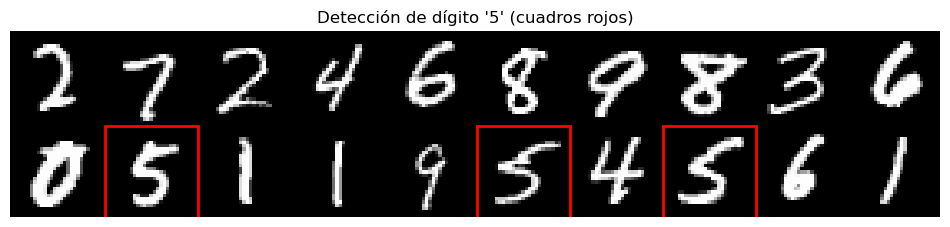

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

# -----------------------------
# Cargar datos reales MNIST
print("Descargando dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data
y = mnist.target.astype(int)

# -----------------------------
# Clasificación binaria: '5' vs no-'5'
y_binary = (y == 5).astype(int)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=0)

# -----------------------------
# Entrenar red neuronal
clf = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=10, random_state=0)
clf.fit(X_train, y_train)
print(f"Precisión en test: {clf.score(X_test, y_test):.2f}")

# -----------------------------
# Crear imagen de prueba: varios dígitos
np.random.seed(42)
canvas = np.zeros((56, 280))  # 56x280 (2 filas de 28 px alto, 10 columnas)
digit_images = []

for _ in range(20):  # 20 dígitos
    idx = np.random.randint(0, len(X_test))
    digit_img = X_test[idx].reshape(28, 28)
    digit_images.append(digit_img)

# Pegar los dígitos en la imagen
for i in range(10):
    canvas[0:28, i*28:(i+1)*28] = digit_images[i]
for i in range(10, 20):
    canvas[28:56, (i-10)*28:(i-9)*28] = digit_images[i]

# -----------------------------
# Detección: barrer con ventana 28x28
detections = []
for row in [0, 28]:
    for col in range(0, canvas.shape[1], 28):
        window = canvas[row:row+28, col:col+28]
        pred = clf.predict(window.reshape(1, -1))
        if pred[0] == 1:
            detections.append((row, col))

# -----------------------------
# Visualización
fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(canvas, cmap='gray')
for (row, col) in detections:
    rect = plt.Rectangle((col, row), 28, 28, edgecolor='red', facecolor='none', lw=2)
    ax.add_patch(rect)
ax.set_title("Detección de dígito '5' (cuadros rojos)")
ax.axis('off')
plt.show()


## Detección de peatones y autos
### Usa un modelo de detección de objetos basado en redes neuronales profundas (*YOLOv8*).  

Procesando: ./fig/Notebook/Yolo\Img1.jpg


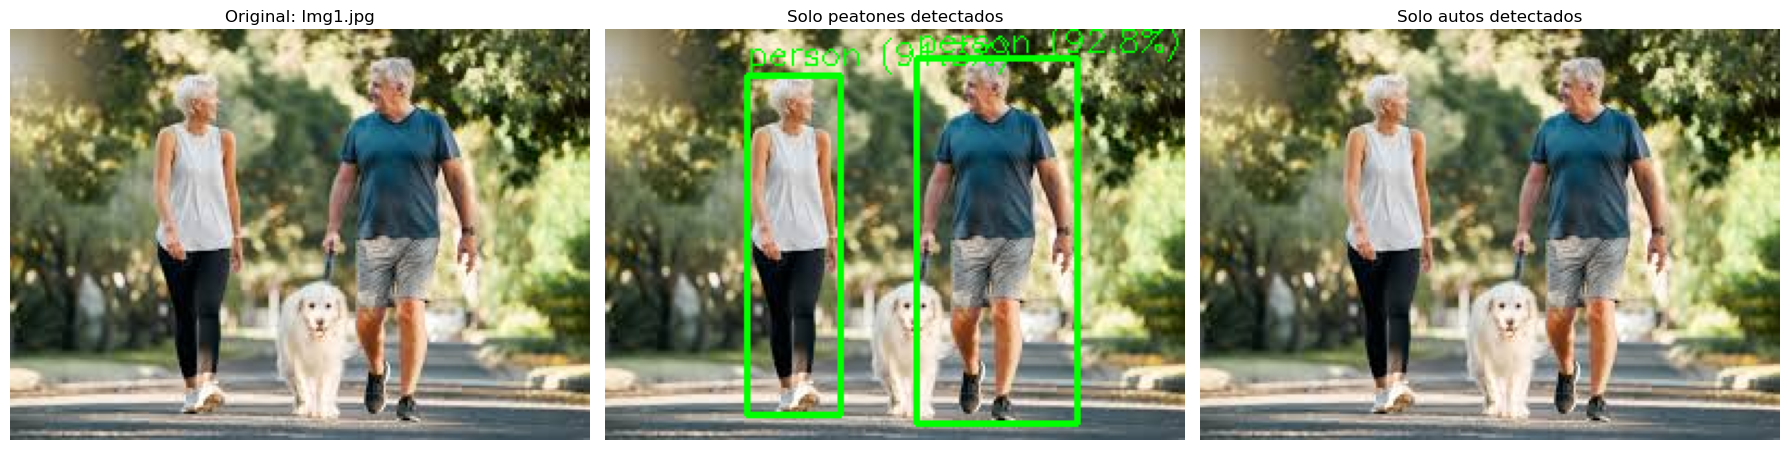

Procesando: ./fig/Notebook/Yolo\Img2.jpg


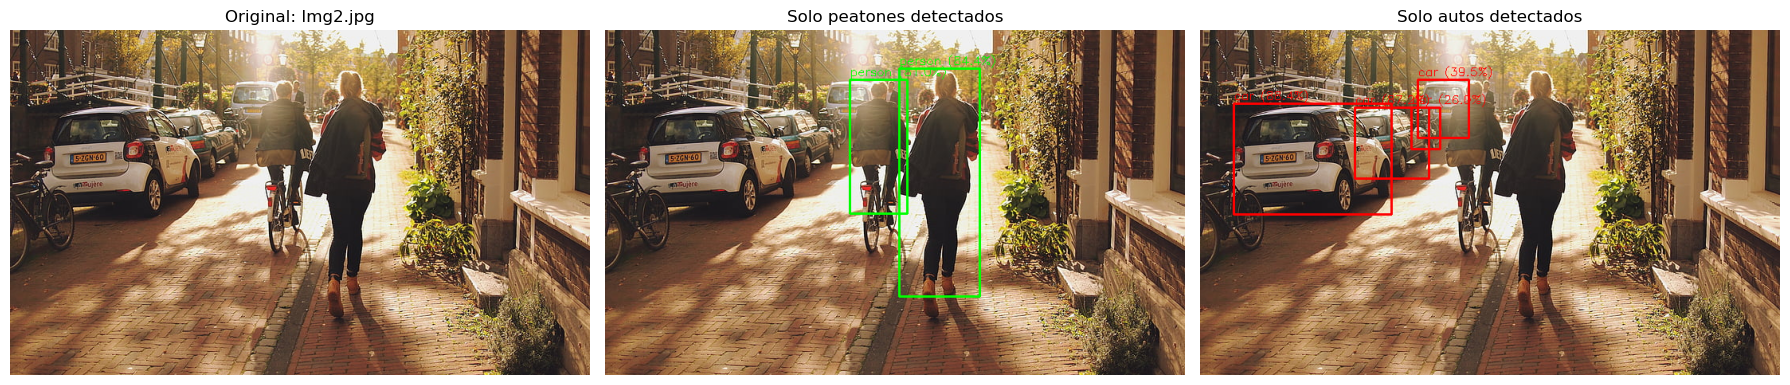

Procesando: ./fig/Notebook/Yolo\Img3.jpg


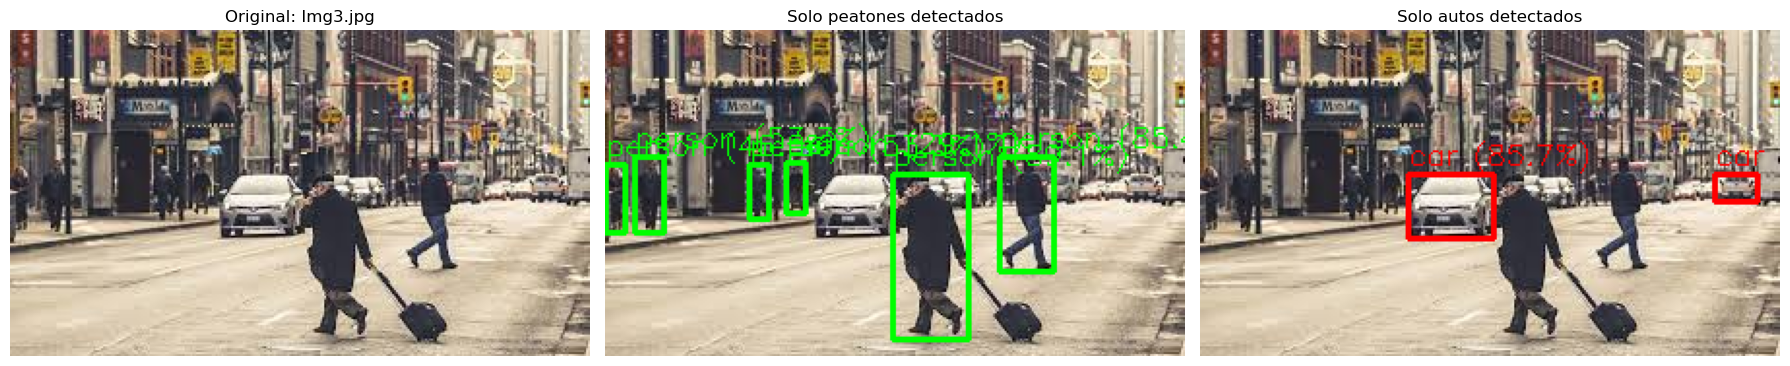

Procesando: ./fig/Notebook/Yolo\Img4.jpg


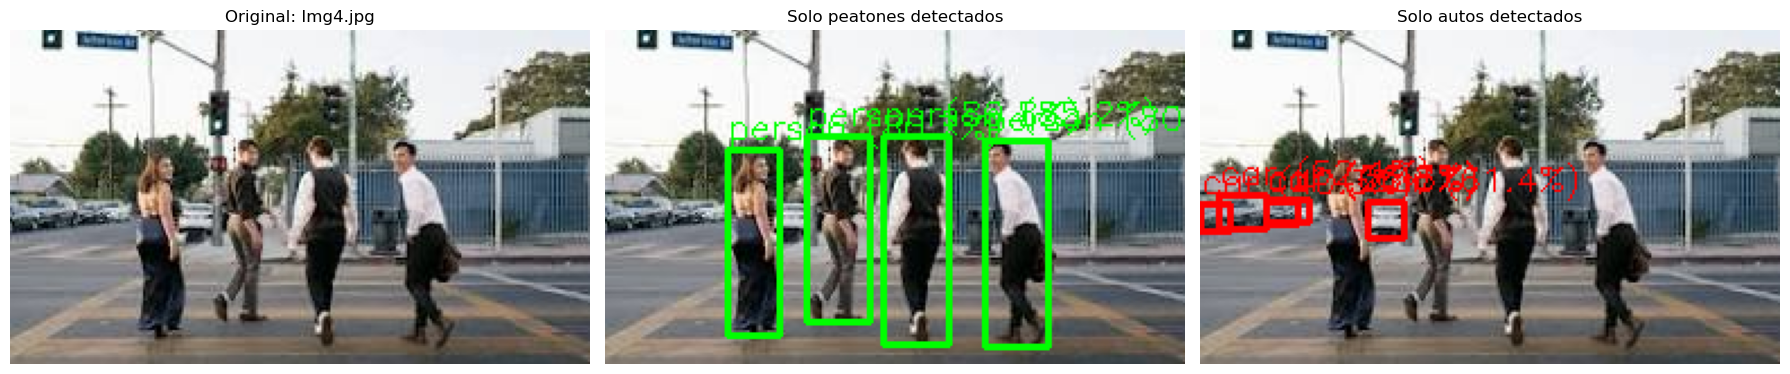

Procesando: ./fig/Notebook/Yolo\Img5.jpg


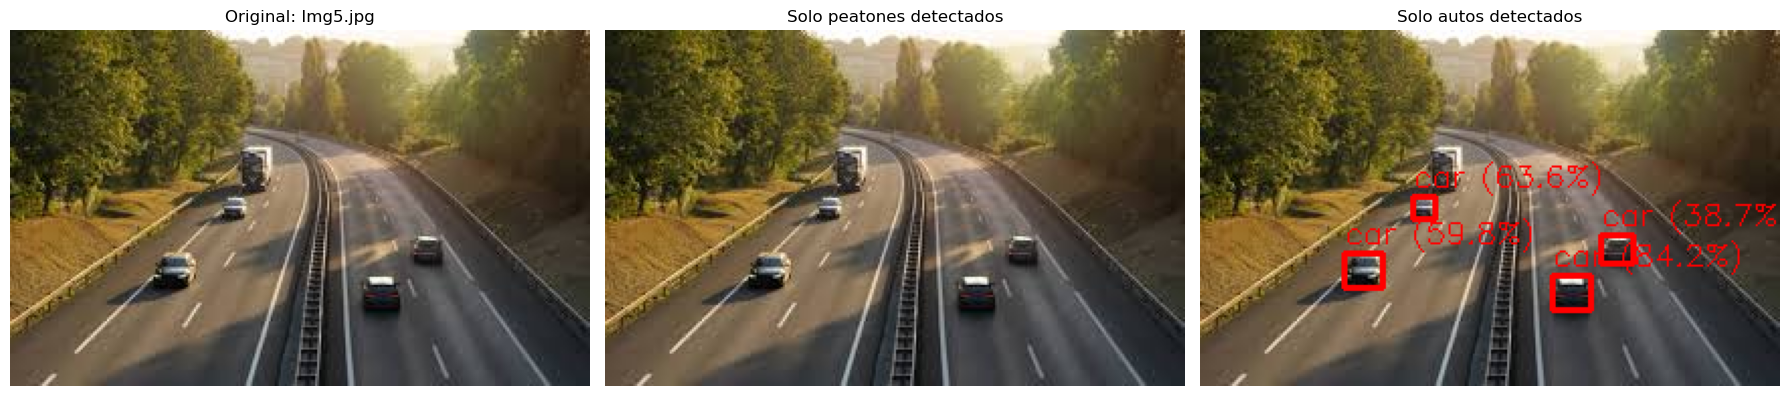

Procesando: ./fig/Notebook/Yolo\Img6.jpg


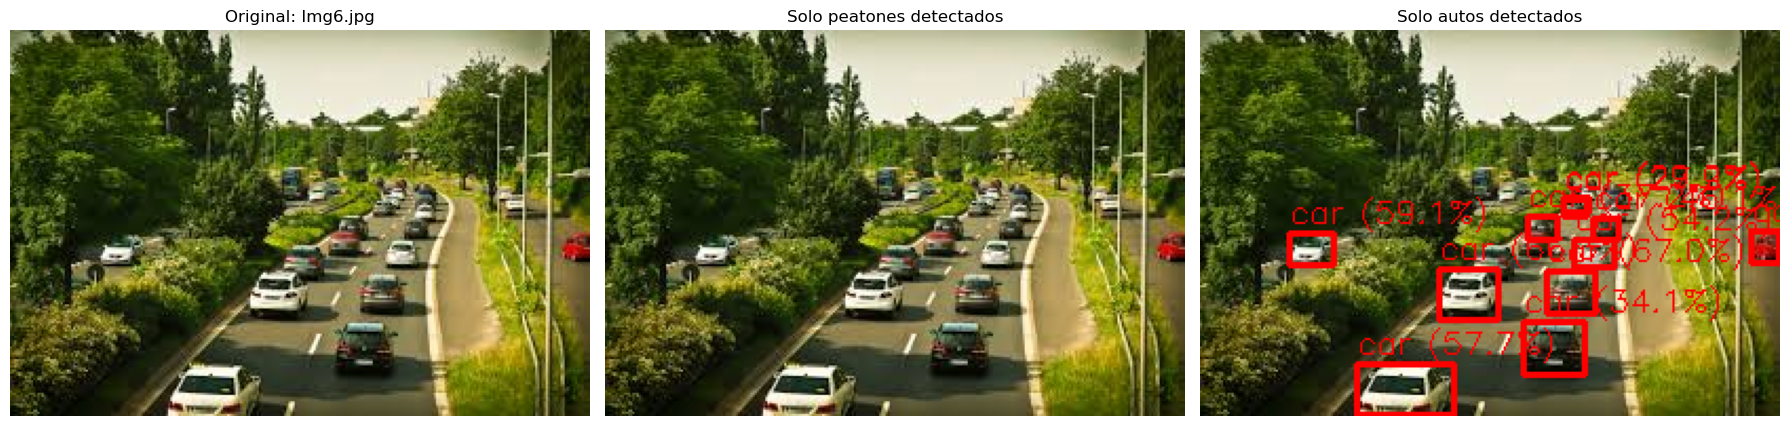

Procesando: ./fig/Notebook/Yolo\Img7.jpg


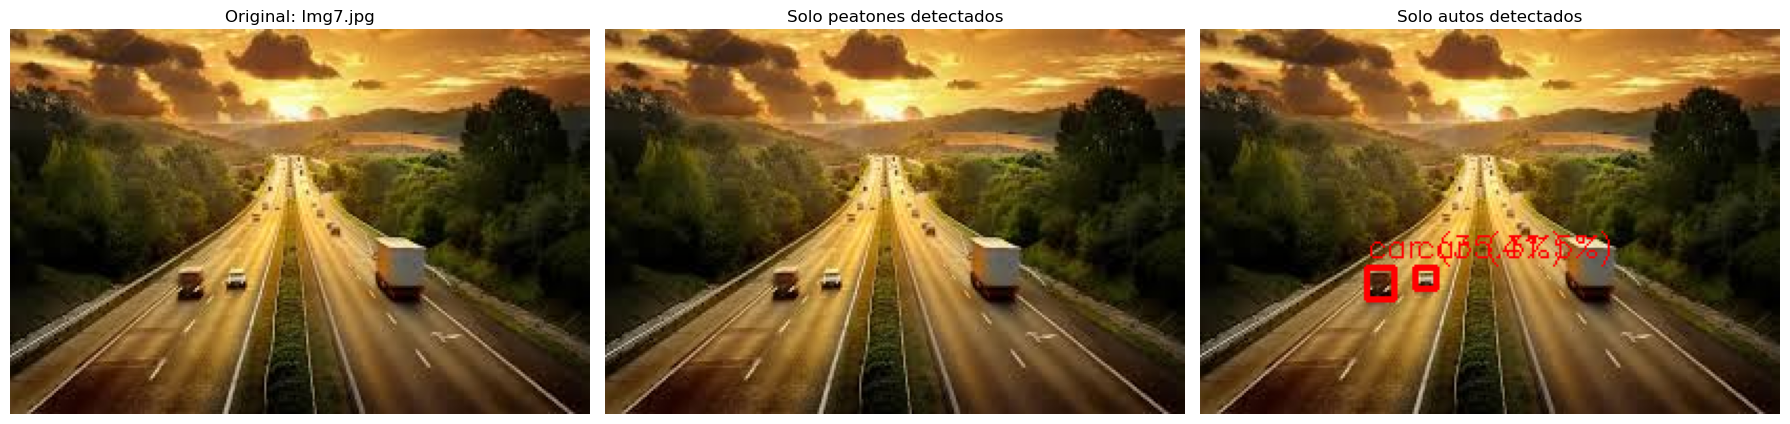

Procesando: ./fig/Notebook/Yolo\Img8.jpg


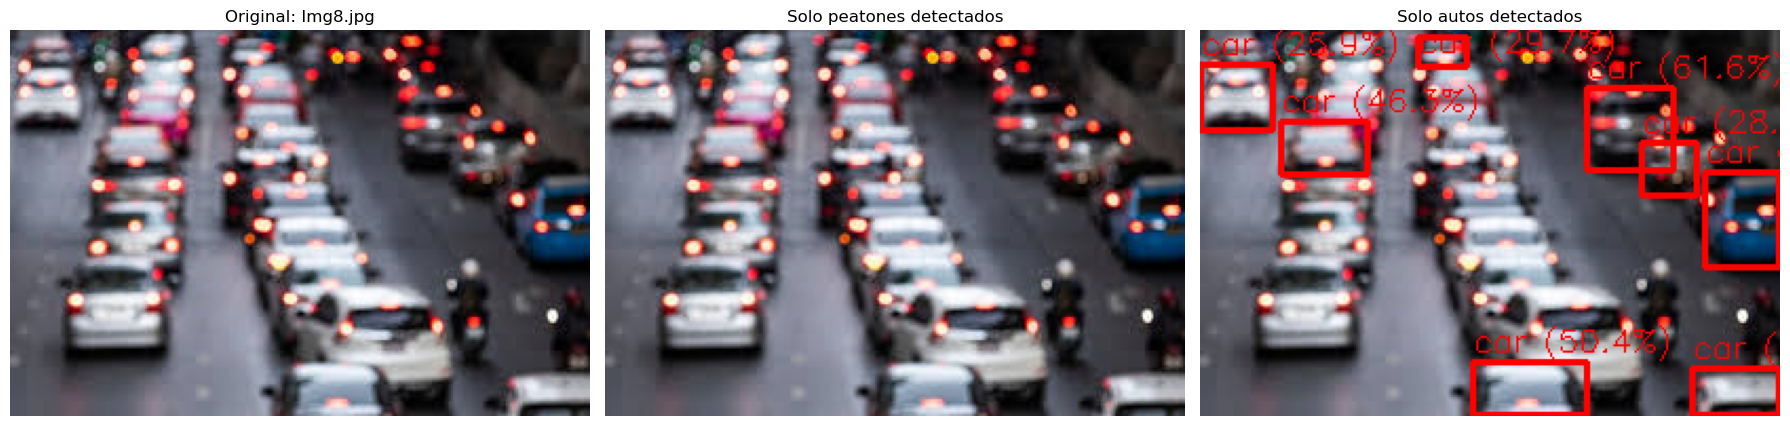

In [44]:
from ultralytics import YOLO
import cv2
import os
import matplotlib.pyplot as plt

# Cargar modelo YOLOv8
model = YOLO('yolov8n.pt')  # o 'yolov8s.pt' para más precisión

# Carpeta con imágenes
carpeta = './fig/Notebook/Yolo'
imagenes = [f for f in os.listdir(carpeta) if f.lower().endswith(('.jpg', '.png'))]

for nombre in imagenes:
    ruta = os.path.join(carpeta, nombre)
    print(f"Procesando: {ruta}")

    # Leer imagen original
    image = cv2.imread(ruta)
    if image is None:
        print(f"No se pudo leer {ruta}")
        continue

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Copias para detecciones
    image_person = image_rgb.copy()
    image_car = image_rgb.copy()

    # Ejecutar detección una sola vez
    results = model(ruta, verbose=False)[0]

    for box in results.boxes:
        cls_id = int(box.cls[0].item())
        label = model.names[cls_id]
        conf = float(box.conf[0].item())
        xyxy = box.xyxy[0].cpu().numpy()
        x1, y1, x2, y2 = map(int, xyxy)
        text = f"{label} ({conf*100:.1f}%)"

        if label == 'person':
            cv2.rectangle(image_person, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(image_person, text, (x1, max(y1-5, 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

        elif label == 'car':
            cv2.rectangle(image_car, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(image_car, text, (x1, max(y1-5, 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

    # Mostrar 3 imágenes lado a lado
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.title(f'Original: {nombre}')
    plt.axis('off')
    plt.imshow(image_rgb)

    plt.subplot(1, 3, 2)
    plt.title('Solo peatones detectados')
    plt.axis('off')
    plt.imshow(image_person)

    plt.subplot(1, 3, 3)
    plt.title('Solo autos detectados')
    plt.axis('off')
    plt.imshow(image_car)

    plt.tight_layout()
    plt.show()


# TÉCNICAS DE NORMALIZACIÓN DE DATOS

## Normalización Min-Max del dataset Iris

In [45]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

In [46]:
# 1. Cargar el dataset Iris
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

# Convertir a DataFrame para mejor visualización
df_original = pd.DataFrame(X, columns=feature_names)

print("=== Base de datos original ===")
print(df_original)

# Crear un DataFrame vacío para guardar los datos normalizados
df_normalized = pd.DataFrame(columns=feature_names)

print("\n=== Normalización Min-Max por columna ===")
for col in feature_names:
    # Calcular valores originales
    x_min = df_original[col].min()
    x_max = df_original[col].max()
    
    # Aplicar normalización manualmente
    df_normalized[col] = (df_original[col] - x_min) / (x_max - x_min)
    
    # Calcular valores después de la normalización
    norm_min = df_normalized[col].min()
    norm_max = df_normalized[col].max()
    
    print(f"\nColumna: '{col}'")
    print(f"- Valor mínimo antes de normalizar: {x_min}")
    print(f"- Valor máximo antes de normalizar: {x_max}")
    print(f"- Fórmula aplicada: (x - {x_min}) / ({x_max} - {x_min})")
    print(f"- Valor mínimo después de normalizar: {norm_min}")
    print(f"- Valor máximo después de normalizar: {norm_max}")

# Mostrar la base de datos normalizada completa
print("\n=== Base de datos normalizada ===")
print(df_normalized)

=== Base de datos original ===
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]

=== Norm

## Normalización Z-score (Estandarización)

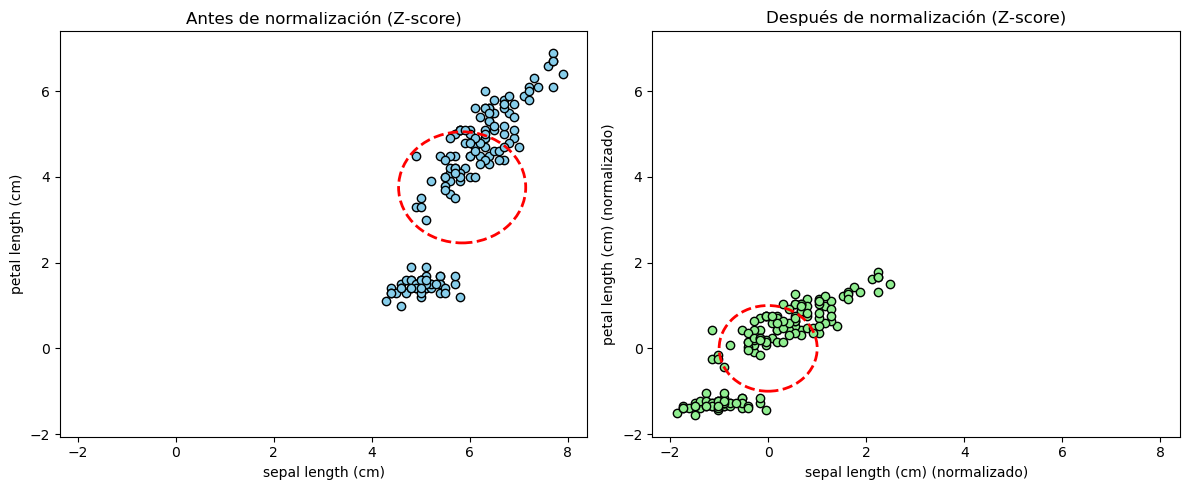

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Cargar el dataset Iris
iris = load_iris()
X = iris.data
feature_names = iris.feature_names
df_original = pd.DataFrame(X, columns=feature_names)

# Seleccionar dos características
col_x = 'sepal length (cm)'
col_y = 'petal length (cm)'

# Calcular medias y desviaciones estándar antes de normalizar
mean_x_orig = df_original[col_x].mean()
mean_y_orig = df_original[col_y].mean()
std_x_orig = df_original[col_x].std()
std_y_orig = df_original[col_y].std()

# Aplicar Z-score normalization manualmente
df_normalized = df_original.copy()
df_normalized[col_x] = (df_original[col_x] - mean_x_orig) / std_x_orig
df_normalized[col_y] = (df_original[col_y] - mean_y_orig) / std_y_orig

# Calcular medias y desviaciones estándar después de normalizar
mean_x_norm = df_normalized[col_x].mean()
mean_y_norm = df_normalized[col_y].mean()
std_x_norm = df_normalized[col_x].std()
std_y_norm = df_normalized[col_y].std()

# Calcular límites globales para que las dos gráficas tengan la misma escala
x_min = min(df_original[col_x].min(), df_normalized[col_x].min()) - 0.5
x_max = max(df_original[col_x].max(), df_normalized[col_x].max()) + 0.5
y_min = min(df_original[col_y].min(), df_normalized[col_y].min()) - 0.5
y_max = max(df_original[col_y].max(), df_normalized[col_y].max()) + 0.5

plt.figure(figsize=(12, 5))

# Antes de normalizar
plt.subplot(1, 2, 1)
plt.scatter(df_original[col_x], df_original[col_y], c='skyblue', edgecolor='black')
plt.title('Antes de normalización (Z-score)')
plt.xlabel(col_x)
plt.ylabel(col_y)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

# Dibujar círculo centrado en la media, radio = desviación estándar promedio
radius_orig = (std_x_orig + std_y_orig) / 2
circle1 = plt.Circle((mean_x_orig, mean_y_orig), radius_orig, color='red', fill=False, linestyle='--', linewidth=2)
plt.gca().add_artist(circle1)

# Después de normalizar
plt.subplot(1, 2, 2)
plt.scatter(df_normalized[col_x], df_normalized[col_y], c='lightgreen', edgecolor='black')
plt.title('Después de normalización (Z-score)')
plt.xlabel(f'{col_x} (normalizado)')
plt.ylabel(f'{col_y} (normalizado)')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

# Dibujar círculo centrado en la media (≈0,0), radio = desviación estándar promedio (≈1)
radius_norm = (std_x_norm + std_y_norm) / 2
circle2 = plt.Circle((mean_x_norm, mean_y_norm), radius_norm, color='red', fill=False, linestyle='--', linewidth=2)
plt.gca().add_artist(circle2)

plt.tight_layout()
plt.show()


## Normalización por norma (L2)

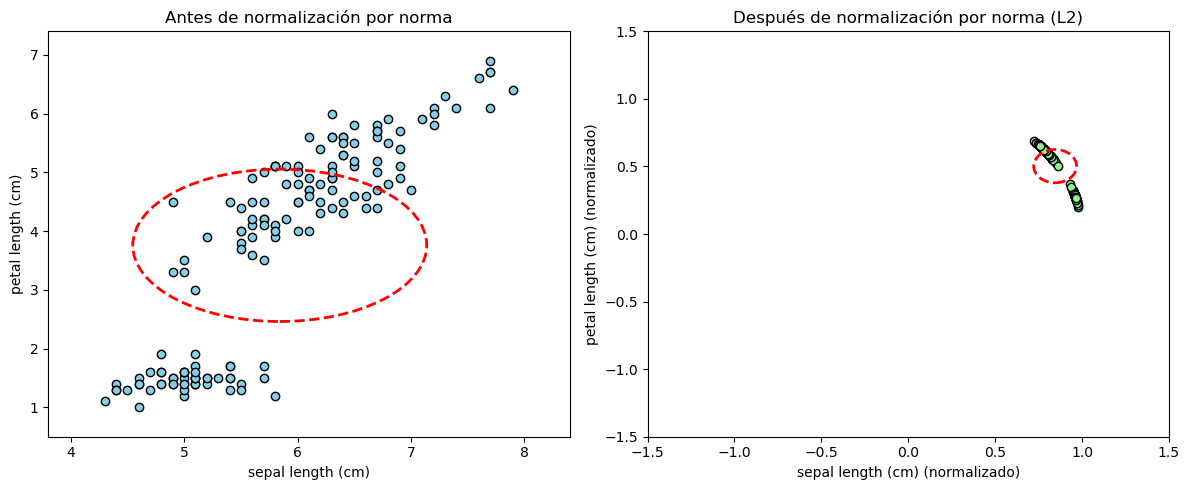

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.datasets import make_classification
from numpy.linalg import norm

# Cargar el dataset Iris
iris = load_iris()
X = iris.data
feature_names = iris.feature_names
df_original = pd.DataFrame(X, columns=feature_names)

# Seleccionar dos características
col_x = 'sepal length (cm)'
col_y = 'petal length (cm)'

# Extraer solo las dos columnas
df_two_features = df_original[[col_x, col_y]].copy()

# Calcular medias y desviaciones estándar antes de normalizar
mean_x_orig = df_two_features[col_x].mean()
mean_y_orig = df_two_features[col_y].mean()
std_x_orig = df_two_features[col_x].std()
std_y_orig = df_two_features[col_y].std()

# Aplicar normalización por norma (norma L2 por fila)
X_two = df_two_features.values
norms = norm(X_two, axis=1, keepdims=True)
X_normalized = X_two / norms

# Crear DataFrame normalizado
df_normalized = pd.DataFrame(X_normalized, columns=[col_x, col_y])

# Calcular medias y desviaciones estándar después de normalizar
mean_x_norm = df_normalized[col_x].mean()
mean_y_norm = df_normalized[col_y].mean()
std_x_norm = df_normalized[col_x].std()
std_y_norm = df_normalized[col_y].std()

# Calcular límites para las gráficas
# Primera gráfica: límites según datos originales
x_min_orig = df_two_features[col_x].min() - 0.5
x_max_orig = df_two_features[col_x].max() + 0.5
y_min_orig = df_two_features[col_y].min() - 0.5
y_max_orig = df_two_features[col_y].max() + 0.5

# Segunda gráfica: límites centrados alrededor de cero
x_min_norm = -1.5
x_max_norm = 1.5
y_min_norm = -1.5
y_max_norm = 1.5

plt.figure(figsize=(12, 5))

# Antes de normalizar
plt.subplot(1, 2, 1)
plt.scatter(df_two_features[col_x], df_two_features[col_y], c='skyblue', edgecolor='black')
plt.title('Antes de normalización por norma')
plt.xlabel(col_x)
plt.ylabel(col_y)
plt.xlim(x_min_orig, x_max_orig)
plt.ylim(y_min_orig, y_max_orig)

# Dibujar círculo centrado en la media, radio = desviación estándar promedio
radius_orig = (std_x_orig + std_y_orig) / 2
circle1 = plt.Circle((mean_x_orig, mean_y_orig), radius_orig, color='red', fill=False, linestyle='--', linewidth=2)
plt.gca().add_artist(circle1)

# Después de normalizar
plt.subplot(1, 2, 2)
plt.scatter(df_normalized[col_x], df_normalized[col_y], c='lightgreen', edgecolor='black')
plt.title('Después de normalización por norma (L2)')
plt.xlabel(f'{col_x} (normalizado)')
plt.ylabel(f'{col_y} (normalizado)')
plt.xlim(x_min_norm, x_max_norm)
plt.ylim(y_min_norm, y_max_norm)

# Dibujar círculo centrado en la media, radio = desviación estándar promedio
radius_norm = (std_x_norm + std_y_norm) / 2
circle2 = plt.Circle((mean_x_norm, mean_y_norm), radius_norm, color='red', fill=False, linestyle='--', linewidth=2)
plt.gca().add_artist(circle2)

plt.tight_layout()
plt.show()


### Norma 2 con datos sintéticos

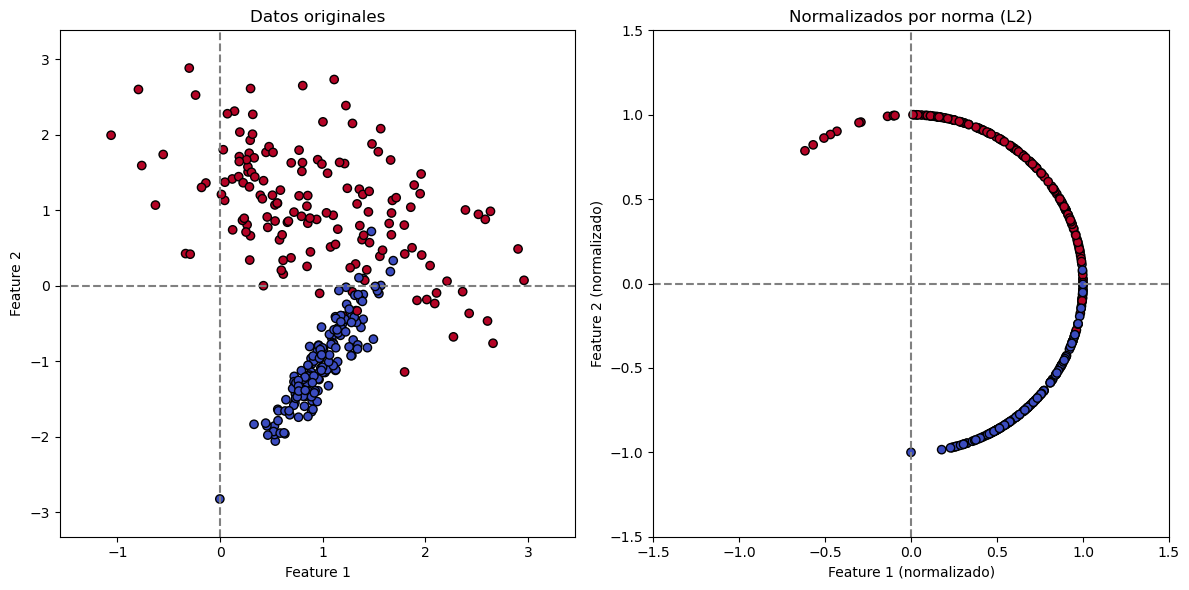

In [49]:
# Generar datos sintéticos de 2 características
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.0,
    random_state=42
)

# Calcular medias y desviaciones estándar antes de normalizar
mean_x_orig = X[:,0].mean()
mean_y_orig = X[:,1].mean()
std_x_orig = X[:,0].std()
std_y_orig = X[:,1].std()

# Normalización por norma L2 por fila
norms = norm(X, axis=1, keepdims=True)
X_norm = X / norms

# Calcular medias y desviaciones estándar después de normalizar
mean_x_norm = X_norm[:,0].mean()
mean_y_norm = X_norm[:,1].mean()
std_x_norm = X_norm[:,0].std()
std_y_norm = X_norm[:,1].std()

# Definir límites para ambas gráficas
# Original
x_min_orig = X[:,0].min() - 0.5
x_max_orig = X[:,0].max() + 0.5
y_min_orig = X[:,1].min() - 0.5
y_max_orig = X[:,1].max() + 0.5

# Normalizados
x_min_norm = -1.5
x_max_norm = 1.5
y_min_norm = -1.5
y_max_norm = 1.5

# Crear figura con dos subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Gráfica original
ax1.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='black')
ax1.set_title('Datos originales')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_xlim(x_min_orig, x_max_orig)
ax1.set_ylim(y_min_orig, y_max_orig)
ax1.axhline(0, color='gray', linestyle='--')
ax1.axvline(0, color='gray', linestyle='--')

# Gráfica normalizada
ax2.scatter(X_norm[:,0], X_norm[:,1], c=y, cmap='coolwarm', edgecolor='black')
ax2.set_title('Normalizados por norma (L2)')
ax2.set_xlabel('Feature 1 (normalizado)')
ax2.set_ylabel('Feature 2 (normalizado)')
ax2.set_xlim(x_min_norm, x_max_norm)
ax2.set_ylim(y_min_norm, y_max_norm)
ax2.axhline(0, color='gray', linestyle='--')
ax2.axvline(0, color='gray', linestyle='--')

plt.tight_layout()
plt.show()


## Escalado robusto

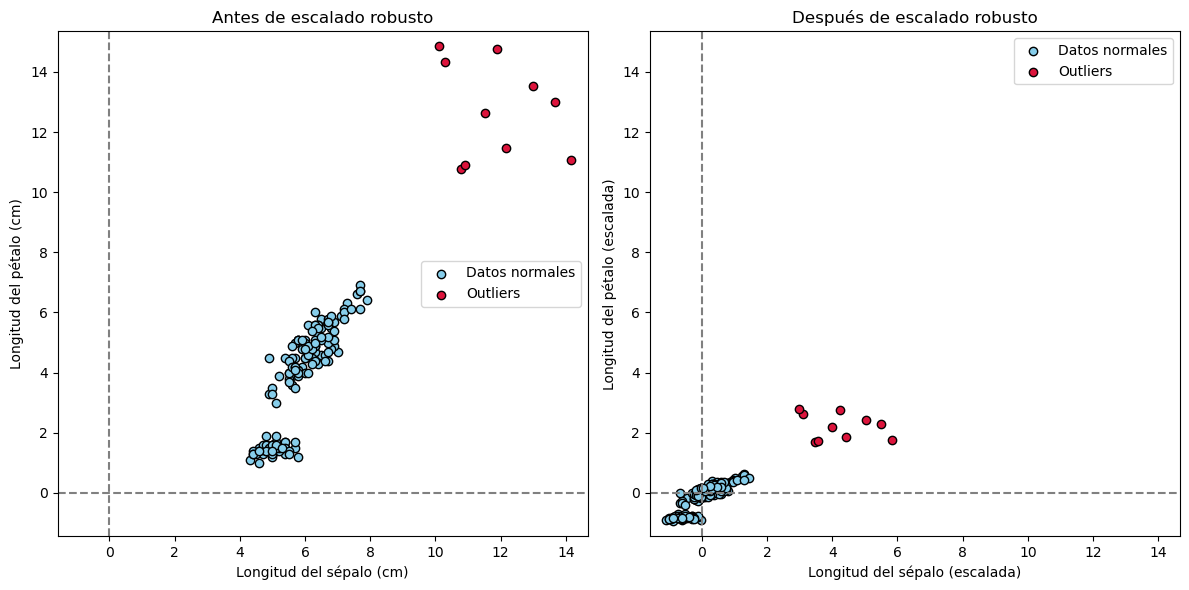

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.datasets import load_iris

# Cargar datos reales de Iris
iris = load_iris()
X_center = iris.data[:, [0, 2]]  # Usamos longitud de sépalo (col 0) y longitud de pétalo (col 2)

# Generar outliers artificiales (fuera del rango normal de Iris)
np.random.seed(42)
outliers = np.random.uniform(low=10, high=15, size=(10, 2))

# Combinar datos originales con los outliers
X = np.vstack([X_center, outliers])

# Escalado robusto
scaler = RobustScaler()
X_robust = scaler.fit_transform(X)

# Marcar los outliers (últimos 10 puntos)
is_outlier = np.zeros(X.shape[0], dtype=bool)
is_outlier[-10:] = True

# Calcular límites comunes para ambas gráficas
all_data = np.vstack([X, X_robust])
x_min = np.min(all_data[:, 0]) - 0.5
x_max = np.max(all_data[:, 0]) + 0.5
y_min = np.min(all_data[:, 1]) - 0.5
y_max = np.max(all_data[:, 1]) + 0.5

# Graficar lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

# Antes del escalado
ax1.scatter(X[~is_outlier,0], X[~is_outlier,1], color='skyblue', edgecolor='black', label='Datos normales')
ax1.scatter(X[is_outlier,0], X[is_outlier,1], color='crimson', edgecolor='black', label='Outliers')
ax1.set_title('Antes de escalado robusto')
ax1.set_xlabel('Longitud del sépalo (cm)')
ax1.set_ylabel('Longitud del pétalo (cm)')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax1.axhline(0, color='gray', linestyle='--')
ax1.axvline(0, color='gray', linestyle='--')
ax1.legend()

# Después del escalado
ax2.scatter(X_robust[~is_outlier,0], X_robust[~is_outlier,1], color='skyblue', edgecolor='black', label='Datos normales')
ax2.scatter(X_robust[is_outlier,0], X_robust[is_outlier,1], color='crimson', edgecolor='black', label='Outliers')
ax2.set_title('Después de escalado robusto')
ax2.set_xlabel('Longitud del sépalo (escalada)')
ax2.set_ylabel('Longitud del pétalo (escalada)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
ax2.axhline(0, color='gray', linestyle='--')
ax2.axvline(0, color='gray', linestyle='--')
ax2.legend()

plt.tight_layout()
plt.show()


## Escalado decimal

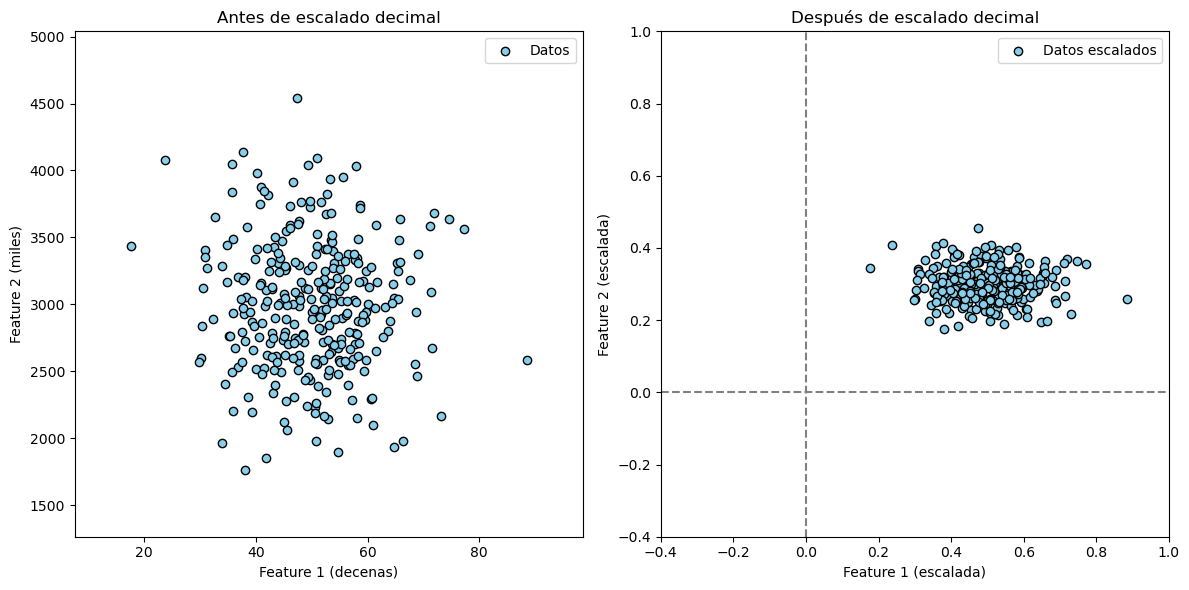

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Generar datos con diferentes escalas
np.random.seed(42)

# Feature 1: decenas
X1 = 50 + 10 * np.random.randn(300, 1)

# Feature 2: miles
X2 = 3000 + 500 * np.random.randn(300, 1)

# Unir en matriz
X = np.hstack([X1, X2])

# Escalado decimal
X_scaled = np.copy(X)
for col in range(X.shape[1]):
    max_abs = np.max(np.abs(X[:, col]))
    d = math.ceil(math.log10(max_abs + 1e-8))
    X_scaled[:, col] = X[:, col] / (10**d)

# Calcular límites
# Para la gráfica normalizada usamos rango fijo: 
norm_x_min, norm_x_max = -0.4, 1.0
norm_y_min, norm_y_max = -0.4, 1.0

# Para la gráfica original, márgenes amplios
x_min = np.min(X[:,0]) - 10
x_max = np.max(X[:,0]) + 10
y_min = np.min(X[:,1]) - 500
y_max = np.max(X[:,1]) + 500

# Graficar lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

# Original
ax1.scatter(X[:,0], X[:,1], color='skyblue', edgecolor='black', label='Datos')
ax1.set_title('Antes de escalado decimal')
ax1.set_xlabel('Feature 1 (decenas)')
ax1.set_ylabel('Feature 2 (miles)')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax1.axhline(0, color='gray', linestyle='--')
ax1.axvline(0, color='gray', linestyle='--')
ax1.legend()

# Escalados
ax2.scatter(X_scaled[:,0], X_scaled[:,1], color='skyblue', edgecolor='black', label='Datos escalados')
ax2.set_title('Después de escalado decimal')
ax2.set_xlabel('Feature 1 (escalada)')
ax2.set_ylabel('Feature 2 (escalada)')
ax2.set_xlim(norm_x_min, norm_x_max)
ax2.set_ylim(norm_y_min, norm_y_max)
ax2.axhline(0, color='gray', linestyle='--')
ax2.axvline(0, color='gray', linestyle='--')
ax2.legend()

plt.tight_layout()
plt.show()


## Transformaciones para distribución: Logarítmica y Box-Cox

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


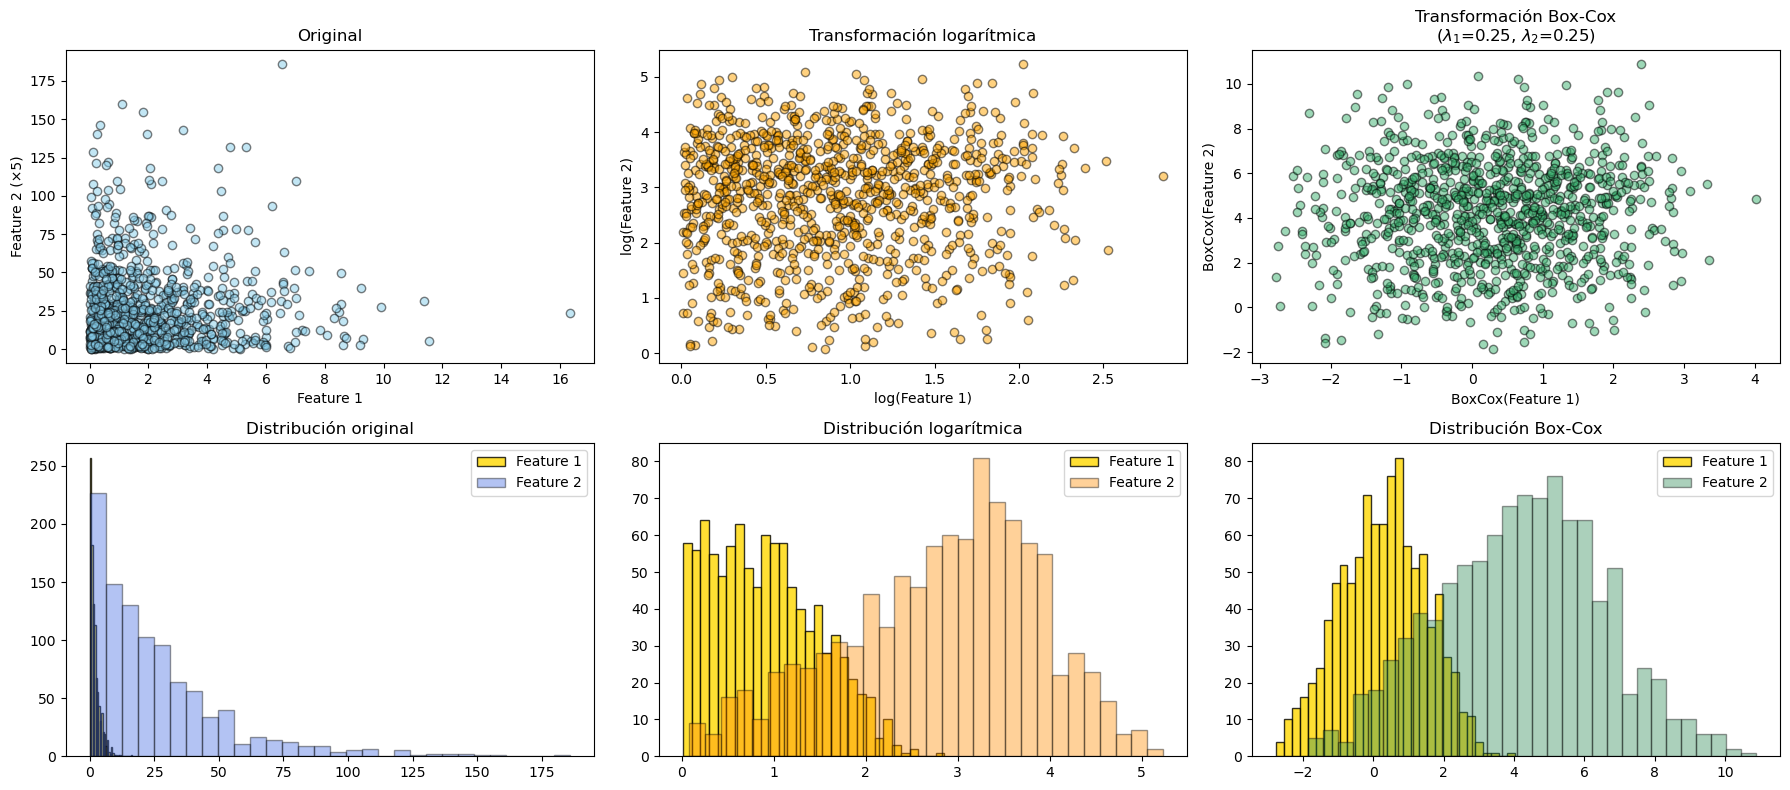

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox

# Generar datos muy asimétricos
np.random.seed(42)
x1 = np.random.exponential(scale=2.0, size=1000)          # Feature 1
x2 = np.random.exponential(scale=5.0, size=1000) * 5      # Feature 2 multiplicada por 5

# Unir en matriz
X = np.column_stack((x1, x2))

# Transformación logarítmica por columna
X_log = np.log1p(X)

# Transformación Box-Cox por columna
X_boxcox = np.zeros_like(X)
lambdas = []

for i in range(X.shape[1]):
    X_boxcox[:, i], λ = boxcox(X[:, i])
    lambdas.append(λ)

# Crear figura con 2 filas y 3 columnas
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

# === FILA 1: Dispersión 2D ===
# Original
axes[0, 0].scatter(X[:, 0], X[:, 1], alpha=0.5, color='skyblue', edgecolor='k')
axes[0, 0].set_title('Original')
axes[0, 0].set_xlabel('Feature 1')
axes[0, 0].set_ylabel('Feature 2 (×5)')

# Log
axes[0, 1].scatter(X_log[:, 0], X_log[:, 1], alpha=0.5, color='orange', edgecolor='k')
axes[0, 1].set_title('Transformación logarítmica')
axes[0, 1].set_xlabel('log(Feature 1)')
axes[0, 1].set_ylabel('log(Feature 2)')

# Box-Cox
axes[0, 2].scatter(X_boxcox[:, 0], X_boxcox[:, 1], alpha=0.5, color='mediumseagreen', edgecolor='k')
axes[0, 2].set_title(f'Transformación Box-Cox\n($\\lambda_1$={lambdas[0]:.2f}, $\\lambda_2$={lambdas[1]:.2f})')
axes[0, 2].set_xlabel('BoxCox(Feature 1)')
axes[0, 2].set_ylabel('BoxCox(Feature 2)')

# === FILA 2: Histogramas (resaltando Feature 1) ===
# Original
axes[1, 0].hist(X[:, 0], bins=30, alpha=0.8, label='Feature 1', color='gold', edgecolor='black')
axes[1, 0].hist(X[:, 1], bins=30, alpha=0.4, label='Feature 2', color='royalblue', edgecolor='black')
axes[1, 0].set_title('Distribución original')
axes[1, 0].legend()

# Log
axes[1, 1].hist(X_log[:, 0], bins=30, alpha=0.8, label='Feature 1', color='gold', edgecolor='black')
axes[1, 1].hist(X_log[:, 1], bins=30, alpha=0.4, label='Feature 2', color='darkorange', edgecolor='black')
axes[1, 1].set_title('Distribución logarítmica')
axes[1, 1].legend()

# Box-Cox
axes[1, 2].hist(X_boxcox[:, 0], bins=30, alpha=0.8, label='Feature 1', color='gold', edgecolor='black')
axes[1, 2].hist(X_boxcox[:, 1], bins=30, alpha=0.4, label='Feature 2', color='seagreen', edgecolor='black')
axes[1, 2].set_title('Distribución Box-Cox')
axes[1, 2].legend()

plt.tight_layout()
plt.show()


# TÉCNICAS DE NORMALIZACIÓN INTERNA

## Batch Normalization

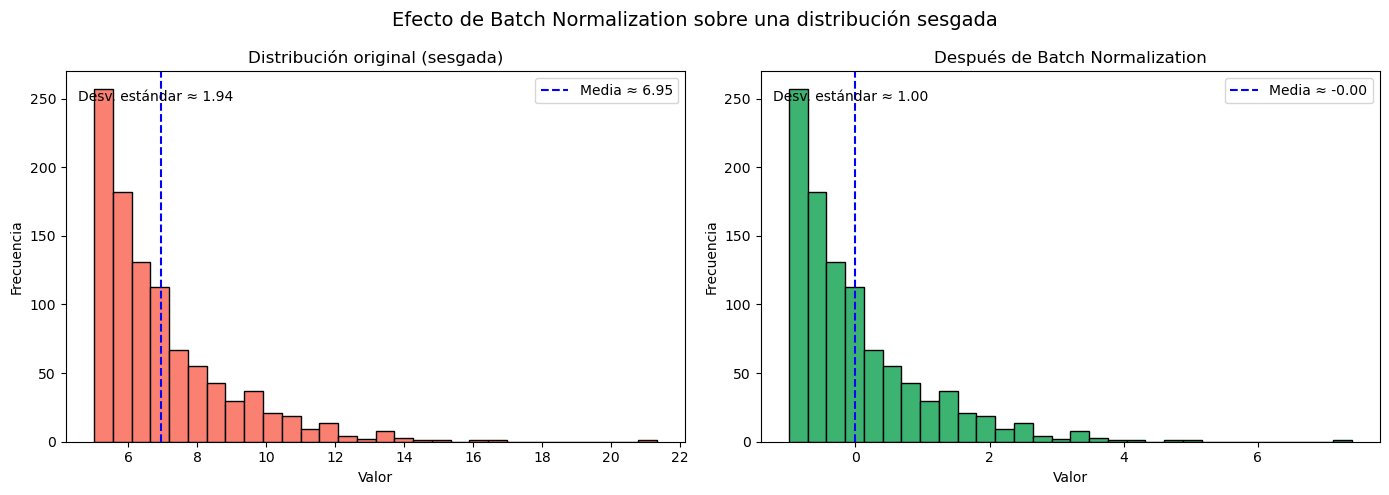

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Generar un batch sesgado (exponencial desplazada)
np.random.seed(42)
batch = np.random.exponential(scale=2.0, size=1000) + 5  # Sesgada a la derecha

# Estadísticas originales
mu_orig = np.mean(batch)
std_orig = np.std(batch)

# Aplicar Batch Normalization
epsilon = 1e-5
mu = np.mean(batch)
var = np.var(batch)
batch_norm = (batch - mu) / np.sqrt(var + epsilon)

# Estadísticas después de normalizar
mu_bn = np.mean(batch_norm)
std_bn = np.std(batch_norm)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# === Histograma original ===
axes[0].hist(batch, bins=30, color='salmon', edgecolor='black')
axes[0].axvline(mu_orig, color='blue', linestyle='--', label=f'Media ≈ {mu_orig:.2f}')
axes[0].set_title('Distribución original (sesgada)')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].text(0.02, 0.95, f'Desv. estándar ≈ {std_orig:.2f}',
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top')

# === Histograma normalizado ===
axes[1].hist(batch_norm, bins=30, color='mediumseagreen', edgecolor='black')
axes[1].axvline(mu_bn, color='blue', linestyle='--', label=f'Media ≈ {mu_bn:.2f}')
axes[1].set_title('Después de Batch Normalization')
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].text(0.02, 0.95, f'Desv. estándar ≈ {std_bn:.2f}',
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top')

plt.suptitle('Efecto de Batch Normalization sobre una distribución sesgada', fontsize=14)
plt.tight_layout()
plt.show()

## Layer Normalization

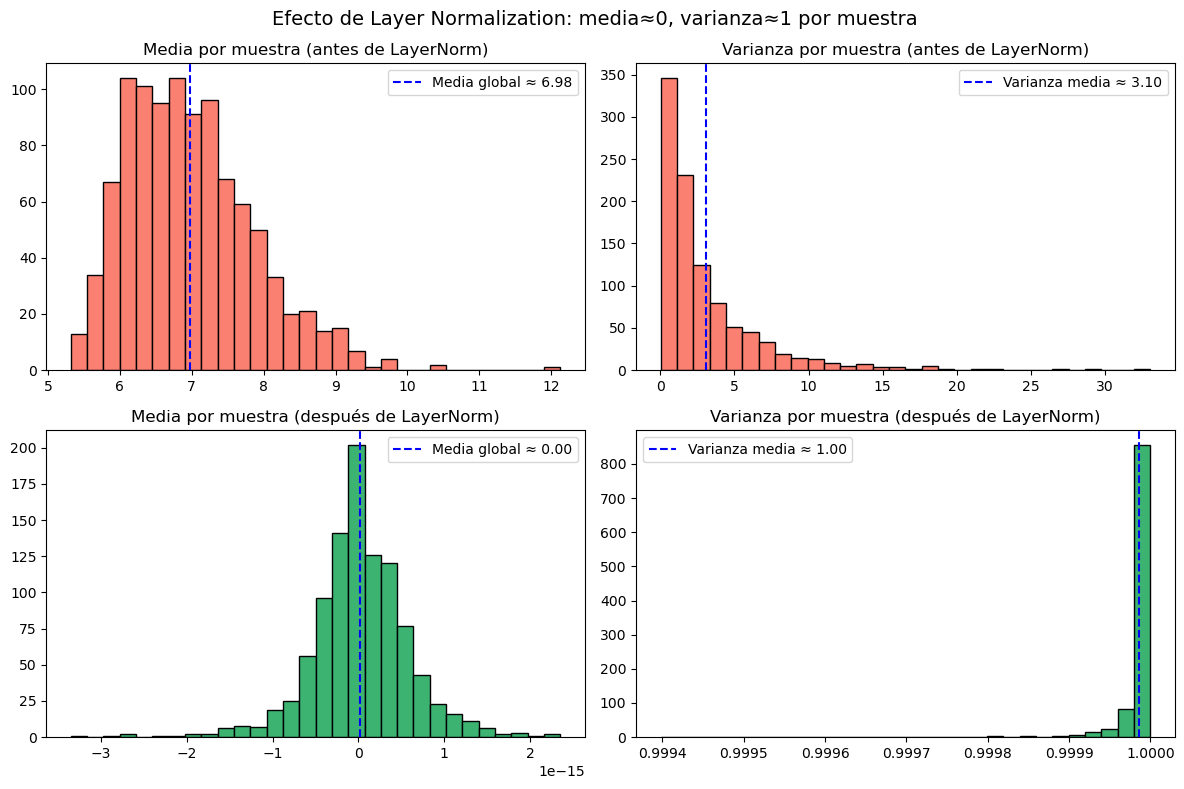

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Crear datos: 1000 muestras, cada una con 5 características sesgadas
np.random.seed(42)
X = np.random.exponential(scale=2.0, size=(1000, 5)) + 5  # datos sesgados

# Aplicar Layer Normalization manualmente
# Para cada muestra (fila), normalizar a media=0, var=1
epsilon = 1e-5
means = np.mean(X, axis=1, keepdims=True)
vars_ = np.var(X, axis=1, keepdims=True)
X_norm = (X - means) / np.sqrt(vars_ + epsilon)

# Comprobar estadísticas
# Calculamos la media y varianza por muestra antes y después
mean_before = np.mean(X, axis=1)
var_before = np.var(X, axis=1)

mean_after = np.mean(X_norm, axis=1)
var_after = np.var(X_norm, axis=1)

# Visualización: histograma de medias y varianzas antes y después
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Histograma medias antes
axes[0,0].hist(mean_before, bins=30, color='salmon', edgecolor='black')
axes[0,0].axvline(np.mean(mean_before), color='blue', linestyle='--', label=f'Media global ≈ {np.mean(mean_before):.2f}')
axes[0,0].set_title('Media por muestra (antes de LayerNorm)')
axes[0,0].legend()

# Histograma varianzas antes
axes[0,1].hist(var_before, bins=30, color='salmon', edgecolor='black')
axes[0,1].axvline(np.mean(var_before), color='blue', linestyle='--', label=f'Varianza media ≈ {np.mean(var_before):.2f}')
axes[0,1].set_title('Varianza por muestra (antes de LayerNorm)')
axes[0,1].legend()

# Histograma medias después
axes[1,0].hist(mean_after, bins=30, color='mediumseagreen', edgecolor='black')
axes[1,0].axvline(np.mean(mean_after), color='blue', linestyle='--', label=f'Media global ≈ {np.mean(mean_after):.2f}')
axes[1,0].set_title('Media por muestra (después de LayerNorm)')
axes[1,0].legend()

# Histograma varianzas después
axes[1,1].hist(var_after, bins=30, color='mediumseagreen', edgecolor='black')
axes[1,1].axvline(np.mean(var_after), color='blue', linestyle='--', label=f'Varianza media ≈ {np.mean(var_after):.2f}')
axes[1,1].set_title('Varianza por muestra (después de LayerNorm)')
axes[1,1].legend()

plt.suptitle('Efecto de Layer Normalization: media≈0, varianza≈1 por muestra', fontsize=14)
plt.tight_layout()
plt.show()

## Ejemplo númerico paso a paso

In [55]:
import numpy as np

np.random.seed(42)

# Arquitectura: [2,3,3,2]
layer_sizes = [2, 3, 3, 2]

# Batch de 4 muestras, datos enteros entre 10 y 20
X = np.random.randint(10, 20, size=(4, 2))

# Inicializar pesos y sesgos (mantienen valores reales)
params = {}
for l in range(1, len(layer_sizes)):
    params[f'W{l}'] = np.random.randn(layer_sizes[l-1], layer_sizes[l])
    params[f'b{l}'] = np.random.randn(1, layer_sizes[l])

# Activación ReLU
def relu(x):
    return np.maximum(0, x)

# BatchNorm por columna
def batch_norm(Z, epsilon=1e-5):
    mean = np.mean(Z, axis=0, keepdims=True)
    var = np.var(Z, axis=0, keepdims=True)
    Z_norm = (Z - mean) / np.sqrt(var + epsilon)
    return Z_norm, mean, var

# LayerNorm por muestra
def layer_norm(Z, epsilon=1e-5):
    mean = np.mean(Z, axis=1, keepdims=True)
    var = np.var(Z, axis=1, keepdims=True)
    Z_norm = (Z - mean) / np.sqrt(var + epsilon)
    return Z_norm, mean, var

print("="*70)
print("Input batch (datos enteros):")
print(X)

A = X

# Forward pass paso a paso
for l in range(1, len(layer_sizes)):
    print("\n" + "="*70)
    print(f"Layer {l}")
    
    W = params[f'W{l}']
    b = params[f'b{l}']
    
    # Mostrar ecuación de la pre-activación
    print(f"\nSe calcula: Z^{l} = A^{l-1} · W^{l} + b^{l}")
    print(f"   A^{l-1}.shape = {A.shape}")
    print(f"   W^{l}.shape = {W.shape}")
    print(f"   b^{l}.shape = {b.shape}")
    
    # Calcular pre-activación
    Z = A @ W + b
    print(f"\nPre-activación Z (shape={Z.shape}):\n{np.round(Z,2)}")
    
    if l != len(layer_sizes)-1:  # Normalizamos en capas ocultas
        # BatchNorm
        Z_bn, mean_bn, var_bn = batch_norm(Z)
        print(f"\nBatchNorm: media por columna: {np.round(mean_bn,2)}")
        print(f"BatchNorm: varianza por columna: {np.round(var_bn,2)}")
        print(f"Z tras BatchNorm:\n{np.round(Z_bn,2)}")
        
        # LayerNorm
        Z_ln, mean_ln, var_ln = layer_norm(Z)
        print(f"\nLayerNorm: media por muestra: {np.round(mean_ln.flatten(),2)}")
        print(f"LayerNorm: varianza por muestra: {np.round(var_ln.flatten(),2)}")
        print(f"Z tras LayerNorm:\n{np.round(Z_ln,2)}")
        
        # Activación (ReLU)
        A_bn = relu(Z_bn)
        A_ln = relu(Z_ln)
        print(f"\nActivación tras BatchNorm (ReLU):\n{np.round(A_bn,2)}")
        print(f"Activación tras LayerNorm (ReLU):\n{np.round(A_ln,2)}")
        
        # Para siguiente capa usamos LayerNorm solo por ejemplo
        A = A_ln
    else:
        # Capa de salida: no normalizamos
        A = Z
        print(f"\nSalida final (sin normalizar):\n{np.round(A,2)}")

print("\n" + "="*70)
print("Output final de la red:")
print(np.round(A,2))


Input batch (datos enteros):
[[16 13]
 [17 14]
 [16 19]
 [12 16]]

Layer 1

Se calcula: Z^1 = A^0 · W^1 + b^1
   A^0.shape = (4, 2)
   W^1.shape = (2, 3)
   b^1.shape = (1, 3)

Pre-activación Z (shape=(4, 3)):
[[      32.56        4.34      -15.29]
 [      34.68        4.65      -16.23]
 [      35.82        1.56      -18.09]
 [      27.87       -0.12      -14.81]]

BatchNorm: media por columna: [[      32.73        2.61       -16.1]]
BatchNorm: varianza por columna: [[       9.24        3.92        1.57]]
Z tras BatchNorm:
[[      -0.06        0.88        0.65]
 [       0.64        1.03        -0.1]
 [       1.01       -0.53       -1.58]
 [       -1.6       -1.38        1.03]]

LayerNorm: media por muestra: [        7.2         7.7        6.43        4.31]
LayerNorm: varianza por muestra: [     385.76      436.65      496.12      313.48]
Z tras LayerNorm:
[[       1.29       -0.15       -1.15]
 [       1.29       -0.15       -1.15]
 [       1.32       -0.22        -1.1]
 [       1.33  

# MÉTRICAS DE EVALUACIÓN

## **Principales métricas en problemas de clasificación**


En tareas de clasificación, se usan varias métricas para evaluar el rendimiento del modelo. Las más comunes son:

- **Accuracy (Exactitud):** proporción de predicciones correctas sobre el total de muestras.
  
  $$
  \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
  $$

- **Precision (Precisión):** mide la proporción de verdaderos positivos entre todas las predicciones positivas.
  
  $$
  \text{Precision} = \frac{TP}{TP + FP}
  $$

- **Recall (Sensibilidad o exhaustividad):** mide la proporción de verdaderos positivos entre todos los positivos reales.
  
  $$
  \text{Recall} = \frac{TP}{TP + FN}
  $$

- **F1-score:** media armónica entre precisión y recall; útil cuando hay clases desbalanceadas.
  
  $$
  \text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
  $$

- **Specificity** (también llamada *True Negative Rate*) mide la proporción de negativos reales que fueron correctamente identificados:

  $$
  \text{Specificity} = \frac{TN}{TN + FP}
  $$

- **Matriz de confusión:** muestra el número de aciertos y errores por clase, permitiendo visualizar dónde se confunde el modelo.

Estas métricas pueden calcularse tanto en problemas de:
- **Clasificación binaria** (2 clases: positivo / negativo)
- **Clasificación multiclase** (3 o más clases)

Visualizar la matriz de confusión ayuda a identificar patrones de error del modelo.

### Clasificación binaria

=== Clasificación binaria ===
       Métrica  Valor
0     Accuracy   0.75
1    Precision   0.75
2       Recall   0.75
3     F1-score   0.75
4  Specificity   0.75

Matriz de confusión:
 [[3 1]
 [1 3]]


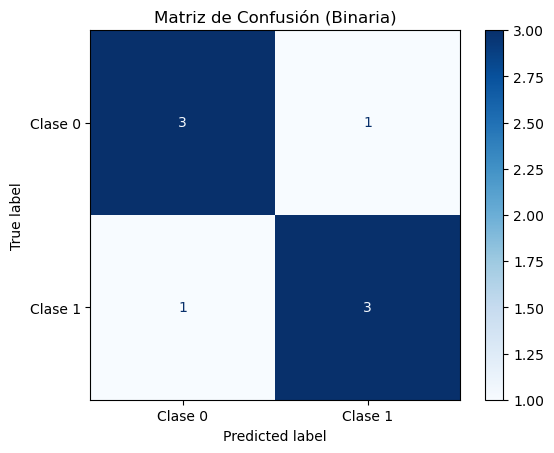

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# -----------------------------
# Clasificación binaria
# -----------------------------
print("=== Clasificación binaria ===")

y_true_bin = np.array([0, 1, 0, 1, 0, 1, 1, 0])
y_pred_bin = np.array([0, 1, 0, 0, 0, 1, 1, 1])

accuracy = accuracy_score(y_true_bin, y_pred_bin)
precision = precision_score(y_true_bin, y_pred_bin)
recall = recall_score(y_true_bin, y_pred_bin)
f1 = f1_score(y_true_bin, y_pred_bin)

# Calcular la matriz de confusión y extraer TN, FP, FN, TP
cm_bin = confusion_matrix(y_true_bin, y_pred_bin, labels=[0,1])
tn, fp, fn, tp = cm_bin.ravel()

# Specificity = TN / (TN + FP)
specificity = tn / (tn + fp)

# Mostrar tabla resumen
metrics_table = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Specificity'],
    'Valor': [accuracy, precision, recall, f1, specificity]
})
print(metrics_table)

print("\nMatriz de confusión:\n", cm_bin)

# Visualización
disp_bin = ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=['Clase 0', 'Clase 1'])
disp_bin.plot(cmap='Blues')
plt.title('Matriz de Confusión (Binaria)')
plt.show()

### Clasificación multiclase


=== Clasificación multiclase ===
Etiquetas reales:    [0 2 2 1 0 0 0 2 1 2 0 2 2 0 0 0 0 1 1 0 1 0 0 0 1 2 0 1 1 0]
Etiquetas predichas: [0 2 2 1 1 0 0 2 1 1 0 2 2 0 0 1 0 1 1 0 1 1 2 0 1 2 0 1 1 0]
Accuracy: 0.83
Reporte detallado:
               precision    recall  f1-score   support

           0       1.00      0.73      0.85        15
           1       0.67      1.00      0.80         8
           2       0.86      0.86      0.86         7

    accuracy                           0.83        30
   macro avg       0.84      0.86      0.83        30
weighted avg       0.88      0.83      0.84        30

Matriz de confusión:
 [[11  3  1]
 [ 0  8  0]
 [ 0  1  6]]


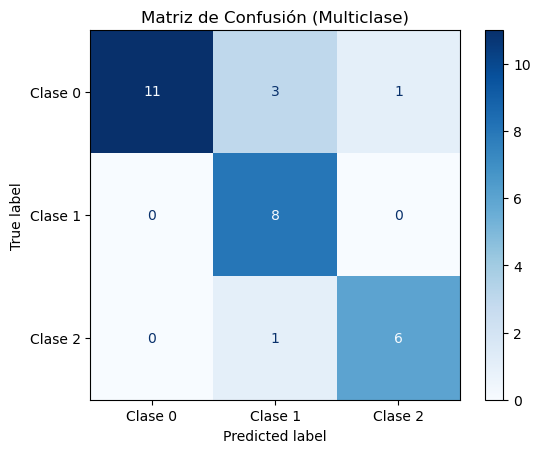

In [57]:
# -----------------------------
# Clasificación multiclase (ejemplo más grande)
# -----------------------------
print("\n=== Clasificación multiclase ===")

# 30 muestras simuladas con 3 clases
np.random.seed(42)
y_true_multi = np.random.choice([0,1,2], size=30, p=[0.4, 0.3, 0.3])
y_pred_multi = y_true_multi.copy()

# Introducimos algunos errores para hacerlo más realista
flip_idx = np.random.choice(len(y_true_multi), size=6, replace=False)
y_pred_multi[flip_idx] = np.random.choice([0,1,2], size=6)

print("Etiquetas reales:   ", y_true_multi)
print("Etiquetas predichas:", y_pred_multi)

accuracy_multi = accuracy_score(y_true_multi, y_pred_multi)
print(f"Accuracy: {accuracy_multi:.2f}")

report = classification_report(y_true_multi, y_pred_multi)
print("Reporte detallado:\n", report)

# Matriz de confusión multiclase (forzando todas las clases)
cm_multi = confusion_matrix(y_true_multi, y_pred_multi, labels=[0,1,2])
print("Matriz de confusión:\n", cm_multi)

# Visualización
disp_multi = ConfusionMatrixDisplay(confusion_matrix=cm_multi, display_labels=['Clase 0','Clase 1','Clase 2'])
disp_multi.plot(cmap='Blues')
plt.title('Matriz de Confusión (Multiclase)')
plt.show()

## Curva ROC

- **ROC (Receiver Operating Characteristic):**  
  Es una curva que muestra el comportamiento del modelo al variar el umbral de decisión.  
  Se construye graficando:
  - **Eje X:** Tasa de Falsos Positivos (*False Positive Rate*, FPR)
  - **Eje Y:** Tasa de Verdaderos Positivos (*True Positive Rate*, TPR), también llamada *Recall*.

- **Cálculo:**
  
  $$
  \text{TPR} = \frac{TP}{TP + FN}
  $$
  
  $$
  \text{FPR} = \frac{FP}{FP + TN}
  $$

---

> La curva ROC permite comparar el rendimiento de diferentes clasificadores, especialmente en contextos donde las clases pueden estar desbalanceadas.

Umbral	TPR	FPR
0.982	0.000	0.000
0.931	0.080	0.000
0.881	0.160	0.000
0.830	0.200	0.000
0.780	0.240	0.000
0.729	0.360	0.000
0.678	0.400	0.000
0.628	0.480	0.000
0.577	0.600	0.040
0.527	0.720	0.120
0.476	0.920	0.160
0.425	0.960	0.200
0.375	1.000	0.280
0.324	1.000	0.400
0.274	1.000	0.520
0.223	1.000	0.560
0.172	1.000	0.640
0.122	1.000	0.680
0.071	1.000	0.840
0.021	1.000	0.960


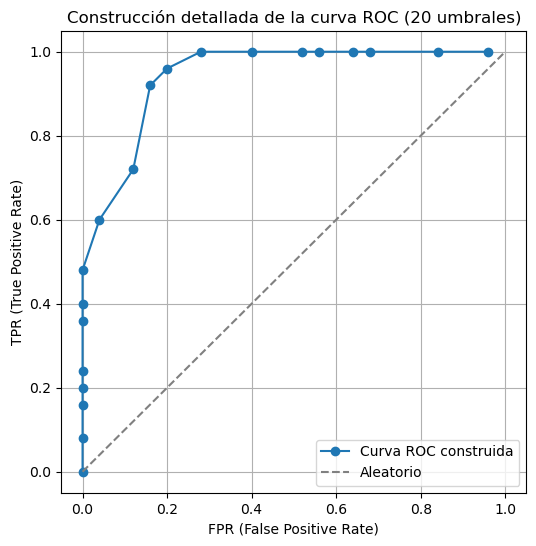

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Semilla para reproducibilidad
np.random.seed(42)

# Simular scores para 50 muestras: 25 positivas y 25 negativas
scores_positive = np.random.uniform(0.4, 1.0, size=25)
scores_negative = np.random.uniform(0.0, 0.6, size=25)

scores = np.concatenate([scores_positive, scores_negative])
y_true = np.array([1]*25 + [0]*25)

# Crear 20 umbrales entre el score mínimo y máximo
thresholds = np.linspace(scores.max(), scores.min(), 20)

print("Umbral\tTPR\tFPR")
tpr_list = []
fpr_list = []

for thresh in thresholds:
    # Predecir clase positiva si score > umbral
    y_pred = (scores > thresh).astype(int)
    
    TP = np.sum((y_pred == 1) & (y_true == 1))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
    
    tpr_list.append(TPR)
    fpr_list.append(FPR)
    
    print(f"{thresh:.3f}\t{TPR:.3f}\t{FPR:.3f}")

# Ordenar puntos para la curva ROC
sorted_points = sorted(zip(fpr_list, tpr_list))

# Graficar curva ROC
plt.figure(figsize=(6,6))
plt.plot([p[0] for p in sorted_points], [p[1] for p in sorted_points],
         marker='o', label='Curva ROC construida')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Aleatorio')
plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate)')
plt.title('Construcción detallada de la curva ROC (20 umbrales)')
plt.legend()
plt.grid(True)
plt.show()


## **AUC (Area Under Curve):**  
  Es el área bajo la curva ROC. Cuanto mayor sea el AUC (más cerca de 1), mejor será la capacidad del modelo para separar correctamente las clases positivas y negativas.


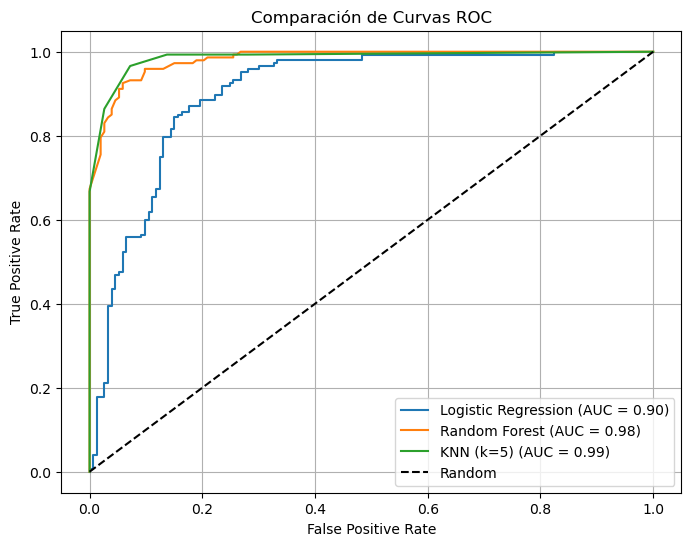

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# -----------------------------
# Generar datos sintéticos (binarios)
# -----------------------------
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2,
                           n_informative=10, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# -----------------------------
# Crear y ajustar varios clasificadores
# -----------------------------
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5)
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train)
    
    # Predecir probabilidades
    y_scores = model.predict_proba(X_test)[:,1]
    
    # Calcular curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    
    # Calcular AUC
    auc = roc_auc_score(y_test, y_scores)
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

# -----------------------------
# Gráfico
# -----------------------------
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparación de Curvas ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## **Métricas de Evaluación en Regresión**

Principales métricas para evaluar el rendimiento de un modelo de regresión:

| **Métrica** | **Ecuación** | **Descripción** |
|-------------|--------------|-----------------|
| **MAE (Mean Absolute Error)** | $\displaystyle \frac{1}{n}\sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|$ | Promedio del valor absoluto de los errores. Representa en qué medida las predicciones se desvían, en promedio, de los valores reales. |
| **MSE (Mean Squared Error)** | $\displaystyle \frac{1}{n}\sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2$ | Promedio de los cuadrados de los errores. Penaliza más fuertemente los errores grandes, lo que puede ayudar a identificar grandes desviaciones. |
| **RMSE (Root Mean Squared Error)** | $\displaystyle \sqrt{\frac{1}{n}\sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2}$ | Raíz cuadrada del MSE. Se interpreta en la misma escala que la variable objetivo, lo que facilita su comprensión. |
| **R² (Coeficiente de determinación)** | $\displaystyle 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$ | Mide qué proporción de la varianza de la variable objetivo es explicada por el modelo. Su valor va de 0 a 1, aunque puede ser negativo si el modelo es muy malo. |
| **MAPE (Mean Absolute Percentage Error)** | $\displaystyle \frac{100}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$ | Error absoluto medio expresado en porcentaje. Permite interpretar el error relativo respecto al valor real. Suele verse afectado por valores reales muy cercanos a cero. |

Estas métricas permiten analizar diferentes aspectos del error del modelo:
- **MAE y RMSE** miden la magnitud promedio del error.
- **MSE** penaliza errores grandes.
- **R²** mide la capacidad explicativa del modelo.
- **MAPE** indica el error en términos relativos porcentuales.

> Elegir una métrica depende del contexto del problema y de la importancia de penalizar o no los errores grandes.


Tabla de métricas de evaluación:
╒═══════════╤════════════════════════════════════════════════════════════════╤═════════╕
│ Métrica   │ Ecuación                                                       │ Valor   │
╞═══════════╪════════════════════════════════════════════════════════════════╪═════════╡
│ MAE       │ $\frac{1}{n}\sum |y_i - \hat{y}_i|$                            │ 2.38    │
├───────────┼────────────────────────────────────────────────────────────────┼─────────┤
│ MSE       │ $\frac{1}{n}\sum (y_i - \hat{y}_i)^2$                          │ 8.83    │
├───────────┼────────────────────────────────────────────────────────────────┼─────────┤
│ RMSE      │ $\sqrt{\frac{1}{n}\sum (y_i - \hat{y}_i)^2}$                   │ 2.97    │
├───────────┼────────────────────────────────────────────────────────────────┼─────────┤
│ R²        │ $1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$  │ 0.812   │
├───────────┼───────────────────────────────────────────────────────────────

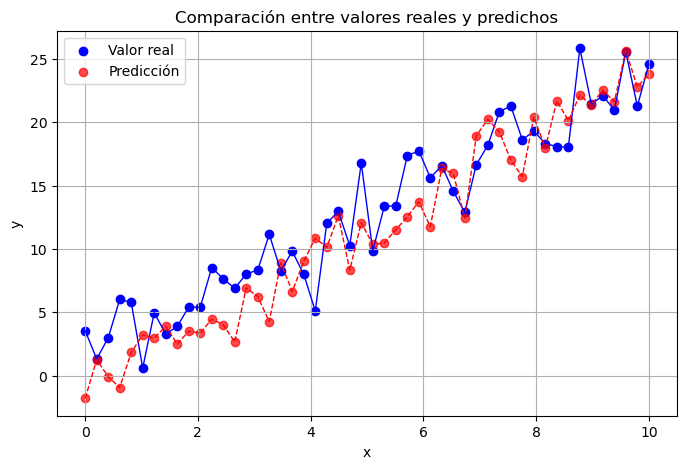

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
from tabulate import tabulate

# Semilla para reproducibilidad
np.random.seed(0)

# -----------------------------
# Generar datos de ejemplo
x = np.linspace(0, 10, 50)
y_true = 2.5 * x + np.random.normal(0, 2, size=len(x))  # verdadero
y_pred = 2.3 * x + np.random.normal(0, 2, size=len(x))  # modelo

# -----------------------------
# Calcular métricas
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# -----------------------------
# Crear tabla con ecuaciones
df = pd.DataFrame({
    'Métrica': ['MAE', 'MSE', 'RMSE', 'R²', 'MAPE'],
    'Ecuación': [
        r"$\frac{1}{n}\sum |y_i - \hat{y}_i|$",
        r"$\frac{1}{n}\sum (y_i - \hat{y}_i)^2$",
        r"$\sqrt{\frac{1}{n}\sum (y_i - \hat{y}_i)^2}$",
        r"$1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$",
        r"$\frac{100}{n}\sum \left| \frac{y_i - \hat{y}_i}{y_i} \right|$"
    ],
    'Valor': [f"{mae:.2f}", f"{mse:.2f}", f"{rmse:.2f}", f"{r2:.3f}", f"{mape:.2f}%"]
})

# -----------------------------
# Imprimir tabla en formato elegante
print("\nTabla de métricas de evaluación:")
print(tabulate(df, headers='keys', tablefmt='fancy_grid', showindex=False))

# -----------------------------
# Gráfica comparativa
plt.figure(figsize=(8,5))
plt.scatter(x, y_true, label='Valor real', color='blue')
plt.scatter(x, y_pred, label='Predicción', color='red', alpha=0.7)
plt.plot(x, y_true, color='blue', linewidth=1)
plt.plot(x, y_pred, color='red', linewidth=1, linestyle='--')
plt.title('Comparación entre valores reales y predichos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()


## **Métricas para Evaluación en Segmentación de Imágenes**

En problemas de segmentación, es fundamental evaluar qué tan bien la máscara predicha se ajusta a la máscara real.  
Las dos métricas más utilizadas son:

| **Métrica** | **Fórmula** | **Descripción** |
|-------------|-------------|-----------------|
| **IoU (Intersection over Union)** | $\displaystyle \text{IoU} = \frac{|A \cap B|}{|A \cup B|}$ | Mide la proporción entre la intersección y la unión de la máscara real ($A$) y la predicha ($B$). Toma valores entre 0 (no solapan nada) y 1 (coinciden perfectamente). |
| **Dice Coefficient** | $\displaystyle \text{Dice} = \frac{2 |A \cap B|}{|A| + |B|}$ | Mide la similitud entre las máscaras, ponderando doble la intersección. También va de 0 a 1. A veces se conoce como F1 score en segmentación. |

### Interpretación:
- **IoU** penaliza más las regiones mal segmentadas fuera de la intersección.
- **Dice** tiende a ser ligeramente más indulgente, ya que pondera más la intersección.

En la práctica:
- Valores cercanos a 1 indican una segmentación excelente.
- Valores bajos (≈0) indican que las máscaras apenas coinciden.

> Estas métricas ayudan a comparar diferentes modelos o ajustar hiperparámetros hasta conseguir una segmentación más precisa.

IoU (Intersection over Union): 0.586
Dice Coefficient: 0.739


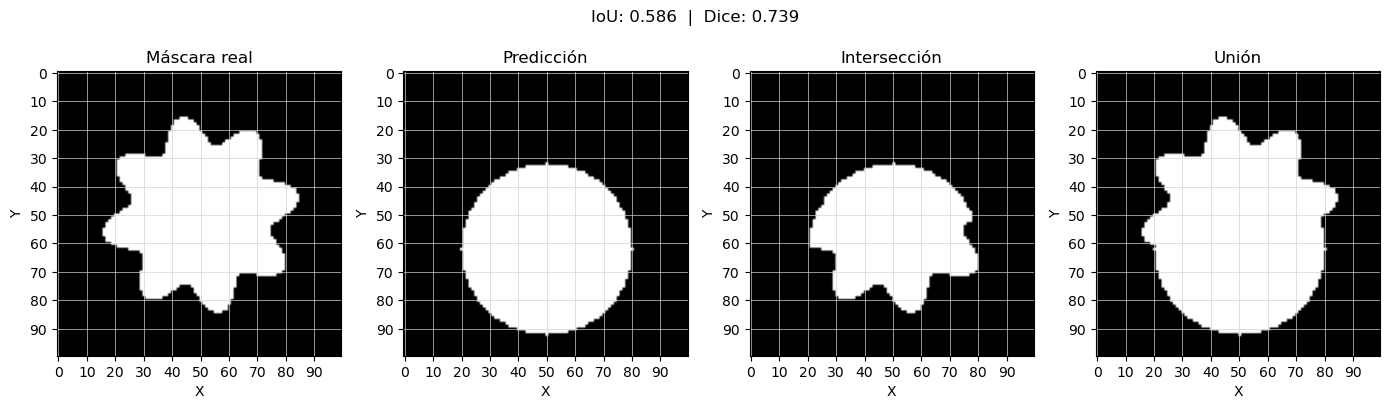

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
size = 100
radius = 30
amplitude = 5           # amplitud de ondulación
frequency = 8           # número de "picos"
shift = int(0.2 * 2*radius)  # desplazamiento: 20% del diámetro

# Coordenadas
rr, cc = np.meshgrid(np.arange(size), np.arange(size))
center = (50, 50)

# -------------------------------
# Máscara real: círculo con ondulaciones sinusoidales
angle = np.arctan2(rr - center[0], cc - center[1])
r = radius + amplitude * np.sin(frequency * angle)
distance = np.sqrt((rr - center[0])**2 + (cc - center[1])**2)
ground_truth = (distance <= r).astype(np.uint8)

# -------------------------------
# Máscara predicha: círculo perfecto desplazado a la derecha
center_pred = (center[0], center[1] + shift)
distance_pred = np.sqrt((rr - center_pred[0])**2 + (cc - center_pred[1])**2)
prediction = (distance_pred <= radius).astype(np.uint8)

# -------------------------------
# Calcular IoU y Dice
intersection = np.logical_and(ground_truth, prediction).sum()
union = np.logical_or(ground_truth, prediction).sum()

iou = intersection / union
dice = 2 * intersection / (ground_truth.sum() + prediction.sum())

print(f"IoU (Intersection over Union): {iou:.3f}")
print(f"Dice Coefficient: {dice:.3f}")

# -------------------------------
# Mostrar resultados gráficos con grid y ejes
fig, axs = plt.subplots(1, 4, figsize=(14, 4))

titles = ['Máscara real', 'Predicción', 'Intersección', 'Unión']
images = [
    ground_truth,
    prediction,
    np.logical_and(ground_truth, prediction),
    np.logical_or(ground_truth, prediction)
]

for ax, img, title in zip(axs, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.grid(True, color='lightgray', linewidth=0.5)
    ax.set_xticks(np.arange(0, size, 10))
    ax.set_yticks(np.arange(0, size, 10))
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.suptitle(f"IoU: {iou:.3f}  |  Dice: {dice:.3f}")
plt.tight_layout()
plt.show()


# Problema de **desbalance de clases** y técnicas de mitigación

Distribución original: [895 105]
Original - Accuracy: 0.973 | F1-score: 0.852
Oversampling - Accuracy: 0.963 | F1-score: 0.836


C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


SMOTE - Accuracy: 0.960 | F1-score: 0.824
Undersampling - Accuracy: 0.973 | F1-score: 0.862


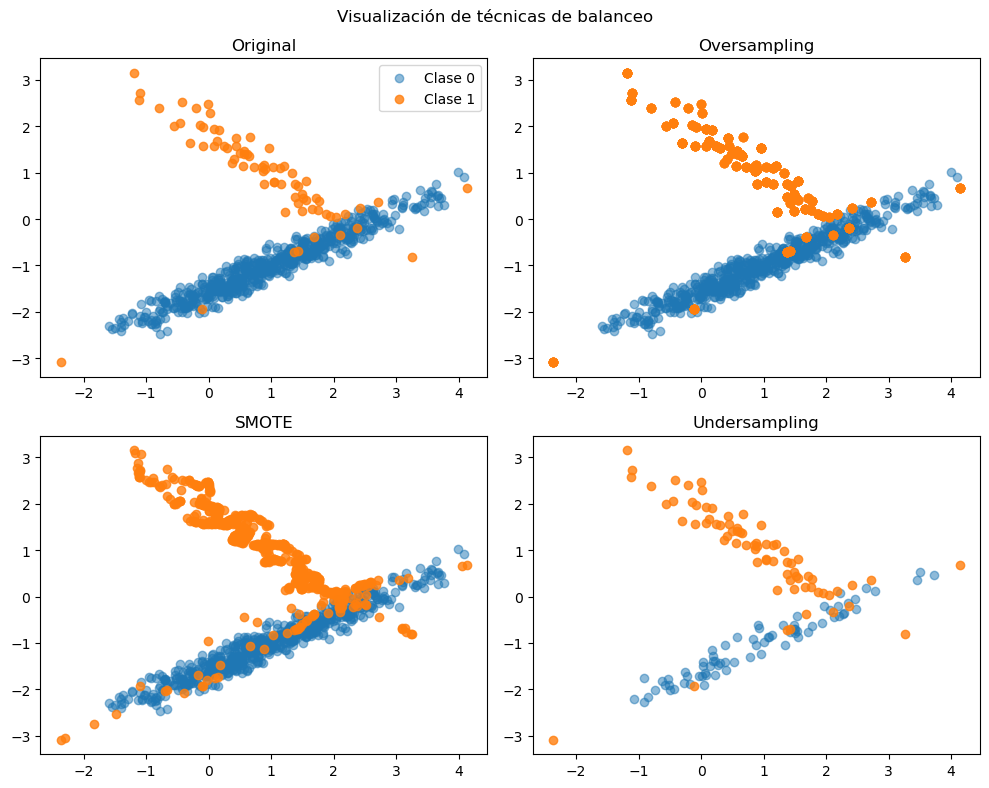


Ajuste de pesos (LogisticRegression) - Accuracy: 0.977 | F1-score: 0.889

Tabla de métricas:
      Técnica  Accuracy  F1-score
     Original  0.973333  0.851852
 Oversampling  0.963333  0.835821
        SMOTE  0.960000  0.823529
Undersampling  0.973333  0.862069
  Weighted LR  0.976667  0.888889


In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
import pandas as pd

# -------------------------------
# Crear dataset desbalanceado
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, weights=[0.9, 0.1],
                           random_state=42)
print("Distribución original:", np.bincount(y))

# -------------------------------
# Dividir en train y test (misma partición para comparar)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, 
                                                    test_size=0.3, random_state=42)

# -------------------------------
# Función para entrenar y evaluar red neuronal
def train_evaluate(X_tr, y_tr, X_te, y_te, description):
    clf = MLPClassifier(hidden_layer_sizes=(10,), max_iter=500, random_state=42)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    print(f"{description} - Accuracy: {acc:.3f} | F1-score: {f1:.3f}")
    return acc, f1

# -------------------------------
# Preparar métricas
results = []

# -------------------------------
# Crear figuras 2x2
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# Original
axes[0].scatter(X_train[y_train==0][:,0], X_train[y_train==0][:,1], alpha=0.5, label='Clase 0')
axes[0].scatter(X_train[y_train==1][:,0], X_train[y_train==1][:,1], alpha=0.8, label='Clase 1')
axes[0].set_title("Original")
axes[0].legend()
acc, f1 = train_evaluate(X_train, y_train, X_test, y_test, "Original")
results.append(["Original", acc, f1])

# -------------------------------
# Oversampling
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)
axes[1].scatter(X_ros[y_ros==0][:,0], X_ros[y_ros==0][:,1], alpha=0.5)
axes[1].scatter(X_ros[y_ros==1][:,0], X_ros[y_ros==1][:,1], alpha=0.8)
axes[1].set_title("Oversampling")
acc, f1 = train_evaluate(X_ros, y_ros, X_test, y_test, "Oversampling")
results.append(["Oversampling", acc, f1])

# -------------------------------
# SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
axes[2].scatter(X_smote[y_smote==0][:,0], X_smote[y_smote==0][:,1], alpha=0.5)
axes[2].scatter(X_smote[y_smote==1][:,0], X_smote[y_smote==1][:,1], alpha=0.8)
axes[2].set_title("SMOTE")
acc, f1 = train_evaluate(X_smote, y_smote, X_test, y_test, "SMOTE")
results.append(["SMOTE", acc, f1])

# -------------------------------
# Undersampling
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)
axes[3].scatter(X_rus[y_rus==0][:,0], X_rus[y_rus==0][:,1], alpha=0.5)
axes[3].scatter(X_rus[y_rus==1][:,0], X_rus[y_rus==1][:,1], alpha=0.8)
axes[3].set_title("Undersampling")
acc, f1 = train_evaluate(X_rus, y_rus, X_test, y_test, "Undersampling")
results.append(["Undersampling", acc, f1])

plt.suptitle("Visualización de técnicas de balanceo")
plt.tight_layout()
plt.show()

# -------------------------------
# Ajuste de pesos en el modelo (LogisticRegression)
clf_weighted = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500)
clf_weighted.fit(X_train, y_train)
y_pred_w = clf_weighted.predict(X_test)
acc_w = accuracy_score(y_test, y_pred_w)
f1_w = f1_score(y_test, y_pred_w)
print(f"\nAjuste de pesos (LogisticRegression) - Accuracy: {acc_w:.3f} | F1-score: {f1_w:.3f}")
results.append(["Weighted LR", acc_w, f1_w])

# -------------------------------
# Mostrar tabla de métricas
df = pd.DataFrame(results, columns=["Técnica", "Accuracy", "F1-score"])
print("\nTabla de métricas:")
print(df.to_string(index=False))
